# Feature Effect Performance Regimes
This notebook assembles a run-scoped regime analysis table for one interpretable-model run, evaluates a selectable feature-effect clustering sweep within performance groups, ranks candidates with conservative quality diagnostics plus DBCV, and exports lean per-candidate cluster artifacts for downstream inspection. The shared 2D UMAP visualization embedding is built only for cluster plots; optional UMAP reductions for clustering and trustworthiness remain available for legacy single-candidate configs.

The sweep choices are explicit tiers: `promising_small` is a compact follow-up around the conservative-filter shortlist, `promising_moderate` is the default workhorse sweep that expands the promising raw/euclidean HDBSCAN and OPTICS neighborhoods, `promising_extended` gives balanced model/algorithm coverage while avoiding the most fragile settings, and `holistic_large` is a broad diagnostic sweep over raw/normalized representations and multiple distance metrics.

| mode | intent | algorithm/space coverage | range logic |
| --- | --- | --- | --- |
| `promising_small` | Fast semantic-inspection rerun around known useful settings. | Raw/euclidean HDBSCAN plus OPTICS; XGBoost OPTICS uses `dbscan_eps` only because the shortlist did. | GAM keeps four low/high min-size fractions and four min-samples values; XGBoost concentrates on the very low fractions that passed filters. |
| `promising_moderate` | Default promising plus worth-exploring sweep. | Raw/euclidean HDBSCAN plus OPTICS with xi and mid/high `dbscan_eps` extraction. | Expands the shortlist neighborhoods with immediate stability neighbors and a 0.05-spaced epsilon quantile grid from 0.20 to 0.85. |
| `promising_extended` | Balanced extended run for comparing GAM/XGBoost and HDBSCAN/OPTICS fairly. | Raw/euclidean HDBSCAN plus OPTICS with the same extraction grid for both models and a mid-density `dbscan_eps` threshold set. | Uses equal-size model grids, excludes very low `min_samples`, and avoids the smallest XGBoost fractions that produced fragmentary/noisy clusters. |
| `holistic_large` | Broad robustness/diagnostic sweep. | Raw and normalized spaces; HDBSCAN euclidean/manhattan; OPTICS euclidean/manhattan/cosine. | Adds wider min-size/min-samples ranges and denser OPTICS xi/epsilon grids; useful for audit runs, not for routine iteration. |


In [ ]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from data_modelling.prepared_data import (
    MODEL_SETTING_COLS,
    load_prepared_data,
    prepare_single_target_model_data,
)
from data_modelling.run_context import (
    format_exported_model_label,
    get_exported_model_info,
    load_run_context,
)
from data_modelling.feature_effect_cluster_exports import write_cluster_exports
from data_modelling.feature_effect_performance_regimes_utils import (
    TRUSTWORTHINESS_COLUMNS,
    assemble_step1_analysis_table,
    assert_columns_present,
    build_effect_cluster_space_matrix,
    build_feature_effect_regime_artifact_names,
    build_feature_effect_regime_export_layout,
    evaluate_umap_trustworthiness_by_group,
    get_effect_cols,
    load_or_initialize_feature_effect_regime_manifest,
    merge_feature_effect_regime_artifact_records,
    resolve_cluster_spec,
    resolve_feature_effect_regime_export_context,
    resolve_raw_metric_col,
    run_step2_clustering,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

MODEL_ID = "xgboost"
RUN_NAME = "full_trainval_12ep_1seed"
EVAL_CSV_NAME = "eval_epoch_12.csv"
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log'
LOWER_IS_BETTER = True
PERFORMANCE_GROUP_COL = "performance_group"
CLUSTER_SWEEP_MODE = "promising_moderate"  # "promising_small", "promising_moderate", "promising_extended", or "holistic_large".
EXPORT_TOP_CANDIDATES_PER_GROUP_ALGORITHM = 3
DOWNSTREAM_MIN_DBCV_RAW_EFFECT_SPACE = 0.0
DOWNSTREAM_MAX_NOISE_FRACTION = 0.75
DOWNSTREAM_QUALITY_FLAG_COLUMNS = [
    "quality_flag_too_many_clusters",
    "quality_flag_dominant_cluster",
]

COMMON_RAW_SWEEP_CLUSTER_SPEC = {
    "groups": ["easy", "medium", "hard"],
    "algorithms": ["hdbscan", "optics"],
    "effect_representations": ["raw"],
    "evaluate_umap_latent_space": False,
    "umap_selected_n_components": {"easy": 3, "medium": 3, "hard": 3},
    "trustworthiness_neighbor_values": [5, 10, 15],
    "cluster_umap_n_neighbors": 30,
    "cluster_umap_min_dist": 0.0,
    "viz_umap_n_neighbors": 15,
    "viz_umap_min_dist": 0.1,
    "random_state": 42,
    "n_jobs": 1,
    "distance_metric": "euclidean",
    "optics_cluster_method": "xi",
    "optics_extraction_methods": ["xi", "dbscan_eps"],
    "optics_xi_values": [0.01, 0.02, 0.05],
    "optics_eps_quantiles": [0.20, 0.50, 0.80],
    "max_noise_fraction": 0.75,
    "max_largest_cluster_share": 0.80,
    "optics_max_largest_cluster_share": 0.85,
    "max_cluster_count": 20,
    "boundary_cluster_size_margin": 1.10,
}

PROMISING_SMALL_COMMON_CLUSTER_SPEC = {
    **COMMON_RAW_SWEEP_CLUSTER_SPEC,
    # Compact semantic-inspection sweep. Keep both algorithms, but spend most of
    # the budget on OPTICS thresholds because the shortlist was mostly OPTICS-led.
    "optics_xi_values": [0.005, 0.02],
    "optics_eps_quantiles": [0.25, 0.35, 0.50, 0.65, 0.80],
}

PROMISING_MODERATE_COMMON_CLUSTER_SPEC = {
    **COMMON_RAW_SWEEP_CLUSTER_SPEC,
    # Workhorse sweep around the useful raw/euclidean neighborhoods observed in
    # the conservative-filter shortlist, with a mid/high OPTICS dbscan_eps grid.
    "optics_xi_values": [0.005, 0.01, 0.015, 0.02, 0.03, 0.05],
    "optics_eps_quantiles": [
        0.20,
        0.25,
        0.30,
        0.35,
        0.40,
        0.45,
        0.50,
        0.55,
        0.60,
        0.65,
        0.70,
        0.75,
        0.80,
        0.85,
    ],
}

PROMISING_EXTENDED_COMMON_CLUSTER_SPEC = {
    **COMMON_RAW_SWEEP_CLUSTER_SPEC,
    # Balanced comparison sweep: keep the same OPTICS extraction grid for both
    # models with a mid-density dbscan-eps grid while avoiding fragile xi values.
    "optics_xi_values": [0.005, 0.01, 0.02],
    "optics_eps_quantiles": [0.15, 0.25, 0.40, 0.55, 0.70, 0.80],
}

HOLISTIC_LARGE_COMMON_CLUSTER_SPEC = {
    **PROMISING_MODERATE_COMMON_CLUSTER_SPEC,
    # Diagnostic expansion for robustness checks, not a practical default.
    "effect_representations": ["raw", "normalized"],
    "distance_metrics": {
        "hdbscan": ["euclidean", "manhattan"],
        "optics": ["euclidean", "manhattan", "cosine"],
    },
    "optics_xi_values": [0.003, 0.005, 0.01, 0.015, 0.02, 0.03, 0.05, 0.08],
    "optics_eps_quantiles": [0.05, 0.10, 0.20, 0.35, 0.50, 0.65, 0.80, 0.90, 0.95],
}

PROMISING_SMALL_CLUSTER_SWEEP_PROFILES = {
    "gam": {
        **PROMISING_SMALL_COMMON_CLUSTER_SPEC,
        # GAM shortlist: useful regions span small hard tails and larger easy/medium
        # OPTICS partitions, so retain both low and high min-cluster-size fractions.
        "min_cluster_size_fractions": [0.003, 0.01, 0.02, 0.04],
        "min_cluster_size_floor": 20,
        "min_samples_values": [3, 10, 20, 40],
    },
    "xgboost": {
        **PROMISING_SMALL_COMMON_CLUSTER_SPEC,
        # XGBoost shortlist concentrated below the old 0.01 floor and almost all
        # selected OPTICS candidates used dbscan-eps extraction.
        "optics_extraction_methods": ["dbscan_eps"],
        "optics_xi_values": [0.005],
        "min_cluster_size_fractions": [0.0015, 0.002, 0.003],
        "min_cluster_size_floor": 10,
        "min_samples_values": [8, 15, 30],
    },
}

PROMISING_MODERATE_CLUSTER_SWEEP_PROFILES = {
    "gam": {
        **PROMISING_MODERATE_COMMON_CLUSTER_SPEC,
        # Covers all GAM shortlist settings plus immediate stability neighbors.
        "min_cluster_size_fractions": [
            0.003,
            0.005,
            0.0075,
            0.01,
            0.015,
            0.02,
            0.03,
            0.04,
        ],
        "min_cluster_size_floor": 20,
        "min_samples_values": [3, 5, 8, 10, 15, 20, 30, 40],
    },
    "xgboost": {
        **PROMISING_MODERATE_COMMON_CLUSTER_SPEC,
        # Covers the low-fraction XGBoost winners and keeps enough larger settings
        # to test whether hard-regime fragments become stable clusters.
        "min_cluster_size_fractions": [
            0.0015,
            0.002,
            0.003,
            0.004,
            0.005,
            0.0075,
            0.01,
            0.015,
            0.02,
            0.03,
        ],
        "min_cluster_size_floor": 10,
        "min_samples_values": [5, 8, 10, 15, 20, 30, 40],
    },
}

PROMISING_EXTENDED_CLUSTER_SWEEP_PROFILES = {
    "gam": {
        **PROMISING_EXTENDED_COMMON_CLUSTER_SPEC,
        # Balanced with XGBoost by grid size, but shifted to GAM's stable min-size range.
        # Excludes min_samples below 10 to avoid tiny satellites and over-fragmentation.
        "min_cluster_size_fractions": [0.003, 0.005, 0.01, 0.02, 0.04],
        "min_cluster_size_floor": 20,
        "min_samples_values": [10, 15, 20, 30, 40],
    },
    "xgboost": {
        **PROMISING_EXTENDED_COMMON_CLUSTER_SPEC,
        # Same grid size as GAM, shifted lower because useful XGBoost partitions
        # appeared at smaller fractions. Avoid 0.001/0.0015 and min_samples < 10,
        # which were prone to noisy hard-regime fragments or over-fragmented easy cases.
        "min_cluster_size_fractions": [0.002, 0.003, 0.005, 0.01, 0.02],
        "min_cluster_size_floor": 10,
        "min_samples_values": [10, 15, 20, 30, 40],
    },
}

HOLISTIC_LARGE_CLUSTER_SWEEP_PROFILES = {
    "gam": {
        **HOLISTIC_LARGE_COMMON_CLUSTER_SPEC,
        "min_cluster_size_fractions": [
            0.002,
            0.003,
            0.005,
            0.0075,
            0.01,
            0.015,
            0.02,
            0.03,
            0.04,
            0.05,
        ],
        "min_cluster_size_floor": 20,
        "min_samples_values": [3, 5, 8, 10, 15, 20, 30, 40, 60],
    },
    "xgboost": {
        **HOLISTIC_LARGE_COMMON_CLUSTER_SPEC,
        "min_cluster_size_fractions": [
            0.001,
            0.0015,
            0.002,
            0.003,
            0.004,
            0.005,
            0.0075,
            0.01,
            0.015,
            0.02,
            0.03,
            0.04,
        ],
        "min_cluster_size_floor": 10,
        "min_samples_values": [2, 3, 5, 8, 10, 15, 20, 30, 40, 60],
    },
}

CLUSTER_SWEEP_PROFILES = {
    "promising_small": PROMISING_SMALL_CLUSTER_SWEEP_PROFILES,
    "promising_moderate": PROMISING_MODERATE_CLUSTER_SWEEP_PROFILES,
    "promising_extended": PROMISING_EXTENDED_CLUSTER_SWEEP_PROFILES,
    "holistic_large": HOLISTIC_LARGE_CLUSTER_SWEEP_PROFILES,
}

if CLUSTER_SWEEP_MODE in CLUSTER_SWEEP_PROFILES:
    CLUSTER_SPEC = CLUSTER_SWEEP_PROFILES[CLUSTER_SWEEP_MODE][MODEL_ID]
else:
    valid_modes = sorted(CLUSTER_SWEEP_PROFILES)
    raise ValueError(
        "CLUSTER_SWEEP_MODE must be one of: "
        f"{', '.join(repr(mode) for mode in valid_modes)}."
    )

CLUSTER_SPEC = json.loads(json.dumps(CLUSTER_SPEC))

## Resolve Run Context and Artifact Paths
**Purpose:** Tie every input and output to one exported modelling run and one joined-metrics file.<br>
**Inputs:** `MODEL_ID`, `RUN_NAME`, `EVAL_CSV_NAME`, optional `TARGET_COL`, and optional prepared-data metadata.<br>
**Outputs:** Resolved modelling-run metadata, joined-metrics source metadata, source artifact paths, and result directories for this notebook run.<br>
**How to Verify:** Confirm the printed target, feature count, model label, and source paths match the exported run you intend to analyze.


In [2]:
run_ctx = load_run_context(MODEL_ID, RUN_NAME, TARGET_COL)
manifest = run_ctx.manifest
target_col = run_ctx.target_col
feature_cols = run_ctx.feature_cols
exported_model_info = get_exported_model_info(manifest)
exported_model_label = format_exported_model_label(exported_model_info)
target_mode = exported_model_info["target_mode"]
raw_metric_col = resolve_raw_metric_col(manifest, target_col)

PREPARED_DATA_PATH = (
    Path("../../results/interpretable_model/prepared_data")
    / RUN_NAME
    / f"prepared_data_{raw_metric_col}.csv"
)
PREPARED_DATA_METADATA_PATH = PREPARED_DATA_PATH.with_suffix(".metadata.json")
prepared_data_metadata = {}
if PREPARED_DATA_METADATA_PATH.exists():
    prepared_data_metadata = json.loads(PREPARED_DATA_METADATA_PATH.read_text())
JOINED_METRICS_RUN_NAME = prepared_data_metadata.get("raw_run_name") or RUN_NAME
FEATURE_EFFECTS_PATH = run_ctx.tables_dir / f"feature_effects_{target_col}.csv"
FEATURE_EFFECT_IMPORTANCE_PATH = (
    run_ctx.tables_dir / f"feature_effect_importance_{target_col}.csv"
)
JOINED_METRICS_PATH = (
    Path("../../results/trajectory_prediction/trajectory_metrics_joined")
    / JOINED_METRICS_RUN_NAME
    / EVAL_CSV_NAME
)
FEATURE_EFFECT_REGIME_RESULTS_ROOT = Path(
    "../../results/interpretable_model/feature_effect_performance_regimes"
)

required_paths = [
    ("prepared data export", PREPARED_DATA_PATH),
    ("feature-effect export", FEATURE_EFFECTS_PATH),
    ("feature-effect importance export", FEATURE_EFFECT_IMPORTANCE_PATH),
    ("joined metrics export", JOINED_METRICS_PATH),
]
for label, path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing required {label}: {path}")

print(f"Run: {RUN_NAME}")
print(f"Eval CSV: {EVAL_CSV_NAME}")
print(f"Exported model: {exported_model_label}")
print(f"Model ID: {MODEL_ID} | target_mode: {target_mode}")
print(f"Resolved target_col: {target_col}")
print(f"Resolved raw_metric_col: {raw_metric_col}")
print(f"Feature count: {len(feature_cols)}")
print(f"Joined metrics run: {JOINED_METRICS_RUN_NAME}")
print(f"Prepared data path: {PREPARED_DATA_PATH}")
print(f"Prepared data metadata path: {PREPARED_DATA_METADATA_PATH}")
print(f"Feature-effect path: {FEATURE_EFFECTS_PATH}")
print(f"Feature-effect ranking path: {FEATURE_EFFECT_IMPORTANCE_PATH}")
print(f"Joined metrics path: {JOINED_METRICS_PATH}")
print(
    f"Feature-effect regime export root: {FEATURE_EFFECT_REGIME_RESULTS_ROOT.resolve()}"
)

Run: full_trainval_12ep_1seed
Eval CSV: eval_epoch_12.csv
Exported model: LinearGAM (no log) (linear, target_mode=raw)
Model ID: gam | target_mode: raw
Resolved target_col: ml_ade_log
Resolved raw_metric_col: ml_ade
Feature count: 5
Prepared data path: ../../results/interpretable_model/prepared_data/full_trainval_12ep_1seed/prepared_data_ml_ade.csv
Feature-effect path: <repo>/results/interpretable_model/gam/full_trainval_12ep_1seed/tables/feature_effects_ml_ade_log.csv
Feature-effect ranking path: <repo>/results/interpretable_model/gam/full_trainval_12ep_1seed/tables/feature_effect_importance_ml_ade_log.csv
Joined metrics path: ../../results/trajectory_prediction/trajectory_metrics_joined/full_trainval_12ep_1seed/eval_epoch_12.csv
Feature-effect regime export root: <repo>/results/interpretable_model/feature_effect_performance_regimes


## Load the Prepared Modelling Table
**Purpose:** Reconstruct the exact modelling rows and feature key used by the interpretable model.<br>
**Inputs:** `PREPARED_DATA_PATH`, resolved `target_col`, resolved `raw_metric_col`, and manifest `feature_cols`.<br>
**Outputs:** `model_df` on the notebook's modelling rows plus a verified feature-key definition.<br>
**How to Verify:** Check that the prepared target and feature columns exactly match the run manifest and that the printed row count looks plausible.


In [3]:
prepared_df = load_prepared_data(
    PREPARED_DATA_PATH,
    display_fn=display,
    include_missing_summary=True,
    include_dtype_summary=True,
)

prepared = prepare_single_target_model_data(
    prepared_df,
    target_col=target_col,
    default_target=raw_metric_col,
    include_model_settings_as_features=any(
        col in MODEL_SETTING_COLS for col in feature_cols
    ),
)
model_df = prepared["model_df"].copy()
prepared_feature_cols = prepared["feature_cols"]

if prepared["target_col"] != target_col:
    raise ValueError(
        f"Prepared target mismatch. expected={target_col}, actual={prepared['target_col']}"
    )
if prepared_feature_cols != feature_cols:
    raise ValueError(
        "Prepared feature columns do not match the run manifest exactly. "
        f"expected={feature_cols}, actual={prepared_feature_cols}"
    )

print(f"Prepared modelling rows: {len(model_df)}")
print(f"Prepared feature key size: {len(prepared_feature_cols)}")

Dataset shape: (26181, 9)
Columns:
['run_name', 'eval_csv_name', 'data_idx', 'std_speed', 'max_speed', 'heading_change_per_sec', 'mean_acceleration', 'min_neighbor_distance', 'ml_ade_log']


,run_name,eval_csv_name,data_idx,std_speed,max_speed,heading_change_per_sec,mean_acceleration,min_neighbor_distance,ml_ade_log
0,full_trainval_12ep_1seed,eval_epoch_12.csv,13538,0.010906,1.188157,1.508442,0.001433,4.615938,0.339062
1,full_trainval_12ep_1seed,eval_epoch_12.csv,23660,0.016326,0.062610,25.081397,-0.002263,2.246425,0.124936
2,full_trainval_12ep_1seed,eval_epoch_12.csv,2863,0.020558,0.070114,103.742011,-0.001067,14.166255,0.066027
3,full_trainval_12ep_1seed,eval_epoch_12.csv,7191,0.182014,1.764128,5.236196,0.049439,1.674341,0.302221
4,full_trainval_12ep_1seed,eval_epoch_12.csv,4839,0.082353,1.829165,4.720065,-0.007304,1.153281,0.457543



Missing values per column:


,missing_count
run_name,0
eval_csv_name,0
data_idx,0
std_speed,0
max_speed,0
heading_change_per_sec,0
mean_acceleration,0
min_neighbor_distance,0
ml_ade_log,0



Column dtypes:


,dtype
run_name,object
eval_csv_name,object
data_idx,int64
std_speed,float64
max_speed,float64
heading_change_per_sec,float64
mean_acceleration,float64
min_neighbor_distance,float64
ml_ade_log,float64


Prepared modelling rows: 26181
Prepared feature key size: 5


## Assemble the Performance-Regime Table
**Purpose:** Join prepared rows, run-scoped metrics, and feature-effect exports, then validate the clustering configuration against the loaded feature-effect columns.<br>
**Inputs:** `model_df`, `JOINED_METRICS_PATH`, `FEATURE_EFFECTS_PATH`, `FEATURE_EFFECT_IMPORTANCE_PATH`, and `CLUSTER_SPEC`.<br>
**Outputs:** `analysis_df`, performance-group summaries, ordered global ranking metadata, resolved clustering config, and the export paths used by the notebook.<br>
**How to Verify:** Confirm the join row counts, the detected feature-effect count, whether optional UMAP reductions are enabled, and the export root before moving on.


In [4]:
def build_trustworthiness_plot_titles(
    cluster_spec: dict[str, object],
) -> dict[str, str]:
    plot_titles = {
        f"nn_{neighbor_value}": (
            "UMAP trustworthiness by reduced dimension and performance group "
            f"(n_neighbors={neighbor_value})"
        )
        for neighbor_value in cluster_spec["trustworthiness_neighbor_values"]
    }
    neighbor_label = ", ".join(
        str(value) for value in cluster_spec["trustworthiness_neighbor_values"]
    )
    plot_titles[cluster_spec["trustworthiness_mean_view"]] = (
        "UMAP trustworthiness by reduced dimension and performance group "
        f"(mean over n_neighbors={neighbor_label})"
    )
    return plot_titles


joined_metrics_df = pd.read_csv(JOINED_METRICS_PATH)
feature_effects_df = pd.read_csv(FEATURE_EFFECTS_PATH)
feature_effect_ranking_df = pd.read_csv(FEATURE_EFFECT_IMPORTANCE_PATH)
assert_columns_present(
    feature_effect_ranking_df,
    [
        "feature",
        "global_rank",
        "importance_metric",
        "importance_value",
        "importance_ascending",
    ],
    df_name="feature-effect ranking export",
)
feature_effect_ranking_df = feature_effect_ranking_df.sort_values(
    ["global_rank", "feature"]
).reset_index(drop=True)

CLUSTER_EFFECT_SELECTION_RULE = "all_feature_effects"
CLUSTER_EFFECT_EXCLUSION_REASON = ""

analysis_df, group_summary_df = assemble_step1_analysis_table(
    prepared_model_df=model_df,
    joined_metrics_df=joined_metrics_df,
    feature_effects_df=feature_effects_df,
    feature_cols=feature_cols,
    target_col=target_col,
    performance_metric_col=raw_metric_col,
    lower_is_better=LOWER_IS_BETTER,
    performance_group_col=PERFORMANCE_GROUP_COL,
    random_state=CLUSTER_SPEC["random_state"],
)

all_effect_cols = get_effect_cols(analysis_df)
effect_cols = list(all_effect_cols)
if MODEL_ID == "gam":
    significance_col = "significant_0_05"
    if significance_col not in feature_effect_ranking_df.columns:
        raise KeyError(
            "GAM feature-effect clustering requires the significance column "
            f"{significance_col!r} in {FEATURE_EFFECT_IMPORTANCE_PATH}."
        )
    significant_features = set(
        feature_effect_ranking_df.loc[
            feature_effect_ranking_df[significance_col].fillna(False).astype(bool),
            "feature",
        ].astype(str)
    )
    effect_cols = [
        col
        for col in all_effect_cols
        if col.removeprefix("effect__") in significant_features
    ]
    if not effect_cols:
        raise ValueError(
            "No significant GAM feature effects remain for clustering. "
            f"Check {FEATURE_EFFECT_IMPORTANCE_PATH}."
        )
    CLUSTER_EFFECT_SELECTION_RULE = "gam_significant_0_05"
    CLUSTER_EFFECT_EXCLUSION_REASON = "gam_not_significant_0_05"

included_effect_features = [col.removeprefix("effect__") for col in effect_cols]
excluded_effect_cols = [col for col in all_effect_cols if col not in set(effect_cols)]
excluded_effect_features = [
    col.removeprefix("effect__") for col in excluded_effect_cols
]
feature_effect_ranking_df["used_for_clustering"] = feature_effect_ranking_df[
    "feature"
].astype(str).isin(included_effect_features)
feature_effect_ranking_df["clustering_exclusion_reason"] = np.where(
    feature_effect_ranking_df["used_for_clustering"],
    "",
    CLUSTER_EFFECT_EXCLUSION_REASON,
)
CLUSTER_SPEC_RESOLVED = resolve_cluster_spec(CLUSTER_SPEC, effect_cols=effect_cols)
EXPORT_CONTEXT = resolve_feature_effect_regime_export_context(
    model_id=MODEL_ID,
    run_name=RUN_NAME,
    target_col=target_col,
    eval_csv_name=EVAL_CSV_NAME,
    lower_is_better=LOWER_IS_BETTER,
    performance_group_col=PERFORMANCE_GROUP_COL,
    results_root=FEATURE_EFFECT_REGIME_RESULTS_ROOT,
)
EXPORT_LAYOUT = build_feature_effect_regime_export_layout(
    export_context=EXPORT_CONTEXT,
    cluster_spec=CLUSTER_SPEC_RESOLVED,
)
ARTIFACT_NAMES = build_feature_effect_regime_artifact_names(
    cluster_spec=CLUSTER_SPEC_RESOLVED
)
TABLES_DIR = EXPORT_LAYOUT["tables_dir"]
PLOTS_DIR = EXPORT_LAYOUT["plots_dir"]
EXPORT_MANIFEST_PATH = EXPORT_LAYOUT["manifest_path"]

REGIME_ANALYSIS_PATH = TABLES_DIR / ARTIFACT_NAMES["tables"]["regime_analysis"]
PERFORMANCE_GROUP_SUMMARY_PATH = (
    TABLES_DIR / ARTIFACT_NAMES["tables"]["performance_group_summary"]
)
UMAP_TRUSTWORTHINESS_PATH = (
    TABLES_DIR / ARTIFACT_NAMES["tables"]["umap_trustworthiness"]
)
CLUSTER_SCORES_PATH = TABLES_DIR / ARTIFACT_NAMES["tables"]["cluster_scores"]
CLUSTER_SCORES_ALL_CANDIDATES_PATH = TABLES_DIR / "cluster_scores_all_candidates.csv"
CLUSTER_ASSIGNMENTS_PATH = TABLES_DIR / ARTIFACT_NAMES["tables"]["cluster_assignments"]
CLUSTER_FEATURE_EFFECT_PROFILES_PATH = (
    TABLES_DIR / ARTIFACT_NAMES["tables"]["cluster_feature_effect_profiles"]
)
CLUSTER_CATALOG_PATH = TABLES_DIR / ARTIFACT_NAMES["tables"]["cluster_catalog"]
FEATURE_EFFECT_GLOBAL_RANKING_PATH = (
    TABLES_DIR / ARTIFACT_NAMES["tables"]["feature_effect_global_ranking"]
)
CANDIDATE_SCORE_HEATMAP_GRID_PATH = (
    PLOTS_DIR / ARTIFACT_NAMES["plots"]["candidate_score_heatmap_grid"]
)
ALGORITHM_CANDIDATE_UMAP_PATH = (
    PLOTS_DIR / ARTIFACT_NAMES["plots"]["algorithm_candidate_umap"]
)
ALGORITHM_CANDIDATE_UMAP_NO_NOISE_PATH = (
    PLOTS_DIR / ARTIFACT_NAMES["plots"]["algorithm_candidate_umap_no_noise"]
)
OPTICS_REACHABILITY_GRID_PATH = (
    PLOTS_DIR / ARTIFACT_NAMES["plots"]["optics_reachability_grid"]
)

if CLUSTER_SPEC_RESOLVED["evaluate_umap_latent_space"]:
    UMAP_TRUSTWORTHINESS_PLOT_PATHS = {
        trustworthiness_view: PLOTS_DIR / plot_name
        for trustworthiness_view, plot_name in ARTIFACT_NAMES["plots"][
            "umap_trustworthiness_curves"
        ].items()
    }
    TRUSTWORTHINESS_PLOT_TITLES = build_trustworthiness_plot_titles(
        CLUSTER_SPEC_RESOLVED
    )
else:
    UMAP_TRUSTWORTHINESS_PLOT_PATHS = {}
    TRUSTWORTHINESS_PLOT_TITLES = {}

group_counts_df = (
    analysis_df[PERFORMANCE_GROUP_COL]
    .value_counts()
    .rename_axis(PERFORMANCE_GROUP_COL)
    .reset_index(name="count")
)

print(f"Joined metrics rows: {len(joined_metrics_df)}")
print(f"Feature-effect rows: {len(feature_effects_df)}")
print(f"Feature ranking rows: {len(feature_effect_ranking_df)}")
print(f"Analysis rows: {len(analysis_df)}")
print(f"Feature-effect columns available: {len(all_effect_cols)}")
print(f"Feature-effect columns used for clustering: {len(effect_cols)}")
print(f"Cluster effect selection rule: {CLUSTER_EFFECT_SELECTION_RULE}")
print(f"Included effect features: {included_effect_features}")
print(f"Excluded effect features: {excluded_effect_features}")
print(
    "Optional UMAP reductions for clustering/trustworthiness: "
    f"{CLUSTER_SPEC_RESOLVED['evaluate_umap_latent_space']}"
)
print(
    f"Resolved optional UMAP candidate dimensions: {CLUSTER_SPEC_RESOLVED['umap_candidate_dims']}"
)
print("2D visualization UMAP: always computed for cluster plots")
print(f"Cluster sweep mode: {CLUSTER_SWEEP_MODE}")
print(f"Parallel clustering jobs: {CLUSTER_SPEC_RESOLVED['n_jobs']}")
print(f"Clustering parameter mode: {CLUSTER_SPEC_RESOLVED['parameter_mode']}")
print(f"Effect representations: {CLUSTER_SPEC_RESOLVED['effect_representations']}")
print(f"Distance metrics by algorithm: {CLUSTER_SPEC_RESOLVED['distance_metrics']}")
print(
    f"OPTICS extraction methods: {CLUSTER_SPEC_RESOLVED['optics_extraction_methods']}"
)
if "dbscan_eps" in CLUSTER_SPEC_RESOLVED["optics_extraction_methods"]:
    print(f"OPTICS eps quantiles: {CLUSTER_SPEC_RESOLVED['optics_eps_quantiles']}")
print(f"Quality screen: {CLUSTER_SPEC_RESOLVED['quality_screen']}")
if CLUSTER_SPEC_RESOLVED["parameter_mode"] == "sweep":
    print(
        f"min_cluster_size fractions: {CLUSTER_SPEC_RESOLVED['min_cluster_size_fractions']}"
    )
    print(f"min_cluster_size floor: {CLUSTER_SPEC_RESOLVED['min_cluster_size_floor']}")
    print(f"min_samples values: {CLUSTER_SPEC_RESOLVED['min_samples_values']}")
print(f"Cluster-spec export root: {EXPORT_LAYOUT['cluster_spec_root']}")
print(f"Export manifest path (manifest.json): {EXPORT_MANIFEST_PATH}")
display(group_summary_df)
display(group_counts_df)
display(feature_effect_ranking_df.head())
display(analysis_df.head())

Joined metrics rows: 26886
Feature-effect rows: 26181
Feature ranking rows: 5
Analysis rows: 26181
Feature-effect columns available: 5
Optional UMAP reductions for clustering/trustworthiness: False
Resolved optional UMAP candidate dimensions: [1, 2, 3, 4]
2D visualization UMAP: always computed for cluster plots
Cluster sweep mode: screen
Parallel clustering jobs: 1
Clustering parameter mode: sweep
Effect representations: ['raw']
Distance metrics by algorithm: {'hdbscan': ['euclidean'], 'optics': ['euclidean']}
OPTICS extraction methods: ['xi', 'dbscan_eps']
OPTICS eps quantiles: [0.2, 0.5, 0.8]
Quality screen: {'max_noise_fraction': 0.6, 'max_largest_cluster_share': 0.8, 'optics_max_largest_cluster_share': 0.85, 'max_cluster_count': 20, 'boundary_cluster_size_margin': 1.1}
min_cluster_size fractions: [0.005, 0.01, 0.02, 0.03]
min_cluster_size floor: 20
min_samples values: [3, 8, 15, 30]
Cluster-spec export root: <repo>/results/interpretable_model/feature_effect_performance_regimes/gam/

,metric_col,centroid_easy,centroid_medium,centroid_hard,boundary_easy_medium,boundary_medium_hard,use_log_space,n_total,n_easy,n_medium,n_hard
0,ml_ade,0.171565,0.643122,1.94186,0.387452,1.198598,True,26181,15377,8117,2687


,performance_group,count
0,easy,15377
1,medium,8117
2,hard,2687


,feature,global_rank,p_value,neg_log10_p_value,significant_0_05,importance_metric,importance_value,importance_ascending
0,heading_change_per_sec,1,1.110223e-16,15.95459,True,p_value,1.110223e-16,True
1,max_speed,2,1.110223e-16,15.95459,True,p_value,1.110223e-16,True
2,mean_acceleration,3,1.110223e-16,15.95459,True,p_value,1.110223e-16,True
3,min_neighbor_distance,4,1.110223e-16,15.95459,True,p_value,1.110223e-16,True
4,std_speed,5,1.110223e-16,15.95459,True,p_value,1.110223e-16,True


,row_id,run_name,eval_csv_name,data_idx,std_speed,max_speed,heading_change_per_sec,mean_acceleration,min_neighbor_distance,ml_ade_log,...,outer_fold,oof_pred_orig,target_orig,effect__std_speed,effect__max_speed,effect__heading_change_per_sec,effect__mean_acceleration,effect__min_neighbor_distance,effect_base_value,performance_group
0,0,full_trainval_12ep_1seed,eval_epoch_12.csv,13538,0.010906,1.188157,1.508442,0.001433,4.615938,0.339062,...,2,0.248173,0.403631,-1.876377,0.453561,-0.266238,0.515301,0.072452,1.329214,medium
1,1,full_trainval_12ep_1seed,eval_epoch_12.csv,23660,0.016326,0.062610,25.081397,-0.002263,2.246425,0.124936,...,3,0.330242,0.133076,-1.879840,0.038846,0.231409,0.511847,0.091045,1.329214,easy
2,2,full_trainval_12ep_1seed,eval_epoch_12.csv,2863,0.020558,0.070114,103.742011,-0.001067,14.166255,0.066027,...,2,-0.022519,0.068256,-1.880872,0.033717,-0.006464,0.512872,0.028511,1.329214,easy
3,3,full_trainval_12ep_1seed,eval_epoch_12.csv,7191,0.182014,1.764128,5.236196,0.049439,1.674341,0.302221,...,1,0.706172,0.352861,-1.678926,0.510704,-0.124584,0.587848,0.063769,1.329214,easy
4,4,full_trainval_12ep_1seed,eval_epoch_12.csv,4839,0.082353,1.829165,4.720065,-0.007304,1.153281,0.457543,...,2,0.425701,0.580186,-1.781812,0.518966,-0.150435,0.508569,0.026094,1.329214,medium


## Visualize Performance Group Distribution
**Purpose:** Show the `ml_ade` distribution coloured by performance group on a linear (clipped) and log1p scale to verify that k-means found meaningful natural breaks.<br>
**Inputs:** `analysis_df`, `group_summary_df`, `raw_metric_col`, and `PERFORMANCE_GROUP_COL`.<br>
**Outputs:** Saved plot at `PERFORMANCE_GROUP_DISTRIBUTION_PATH`.<br>
**How to Verify:** Confirm that the dashed boundary lines align with visible transitions in the histogram and that the table counts match `group_summary_df`.

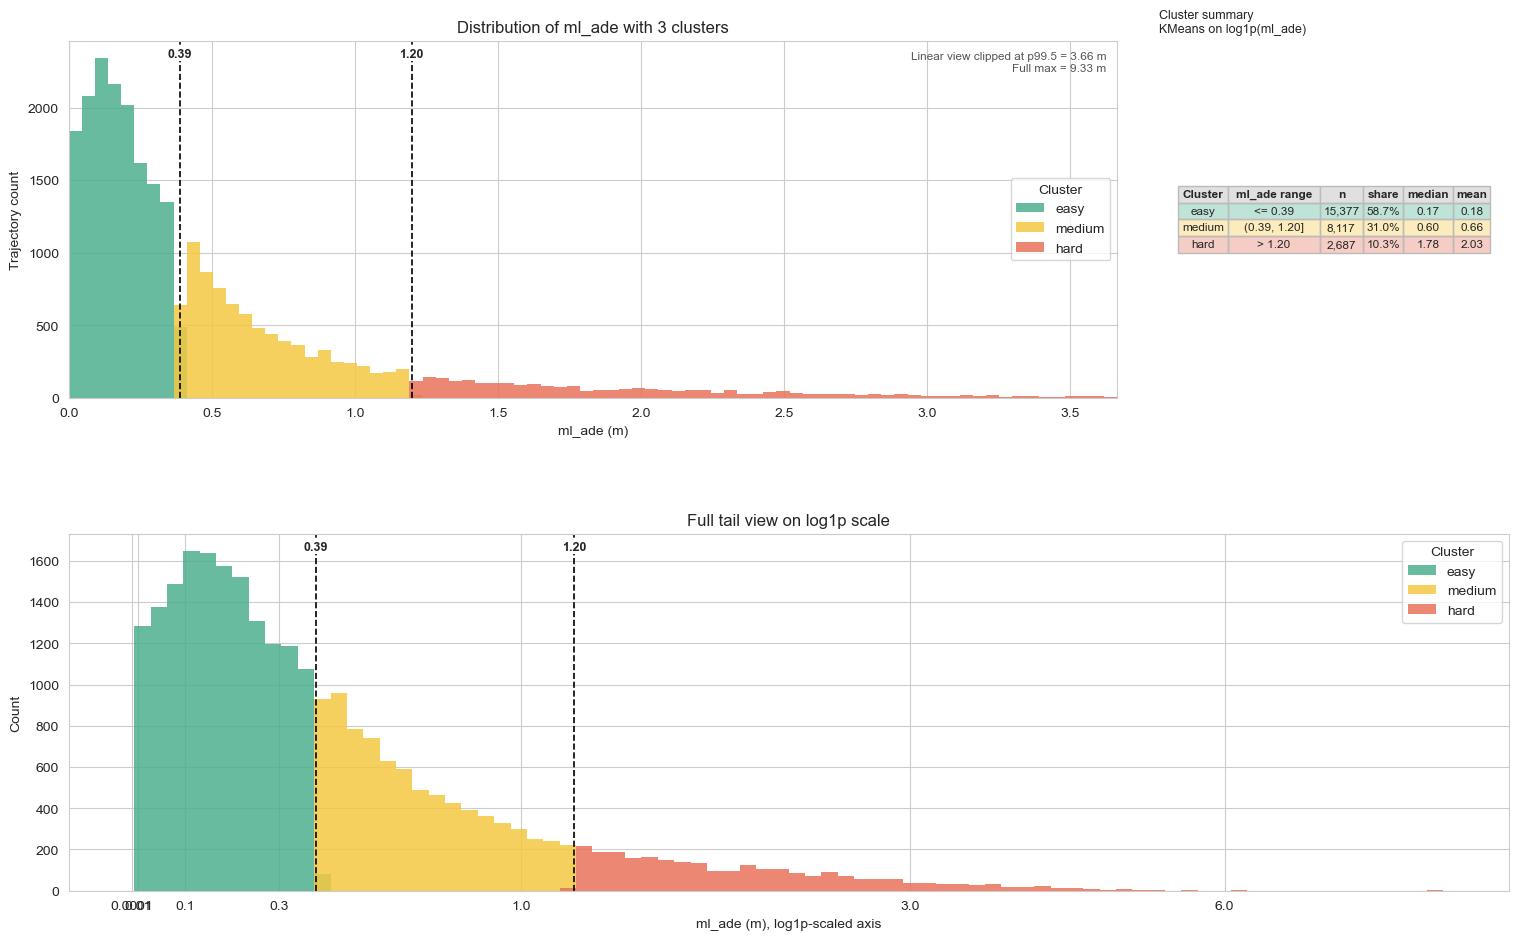

Performance group distribution plot saved to: <repo>/results/interpretable_model/feature_effect_performance_regimes/gam/full_trainval_12ep_1seed/ml_ade_log/target-ml_ade_log__eval-eval_epoch_12.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__spaces-raw__metrics-fc851a24__umap-off__dims-easy3-hard3-medium3__optics-xi-0.01-0.02-0.05__optics-ext-xi-dbscan_eps__mcs-fracs-0.005-0.01-0.02-0.03__trunc-b68e7565__b68e7565c85b/plots/performance_group_distribution_ml_ade.png


In [5]:
import matplotlib.gridspec as gridspec
from matplotlib.colors import to_rgba

PERFORMANCE_GROUP_DISTRIBUTION_PATH = (
    PLOTS_DIR / f"performance_group_distribution_{raw_metric_col}.png"
)

_GROUP_COLORS = {"easy": "#4daf8d", "medium": "#f5c842", "hard": "#e8725a"}
_GROUP_ORDER = ["easy", "medium", "hard"]


def plot_performance_group_distribution(
    analysis_df: pd.DataFrame,
    *,
    performance_metric_col: str,
    performance_group_col: str,
    group_summary_df: pd.DataFrame,
    plot_path: Path,
) -> None:
    metric = analysis_df[performance_metric_col]
    n_total = len(metric)
    clip_val = float(metric.quantile(0.995))
    full_max = float(metric.max())
    boundary_low = float(group_summary_df["boundary_easy_medium"].iloc[0])
    boundary_high = float(group_summary_df["boundary_medium_hard"].iloc[0])

    range_strs = {
        "easy": f"<= {boundary_low:.2f}",
        "medium": f"({boundary_low:.2f}, {boundary_high:.2f}]",
        "hard": f"> {boundary_high:.2f}",
    }
    table_rows = []
    for g in _GROUP_ORDER:
        mask = analysis_df[performance_group_col] == g
        vals = metric[mask]
        n = int(mask.sum())
        table_rows.append(
            [
                g,
                range_strs[g],
                f"{n:,}",
                f"{100 * n / n_total:.1f}%",
                f"{float(vals.median()):.2f}",
                f"{float(vals.mean()):.2f}",
            ]
        )

    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(
        2,
        2,
        width_ratios=[3, 1],
        hspace=0.38,
        wspace=0.06,
        top=0.93,
        bottom=0.08,
        left=0.07,
        right=0.97,
    )
    ax_lin = fig.add_subplot(gs[0, 0])
    ax_tbl = fig.add_subplot(gs[0, 1])
    ax_log = fig.add_subplot(gs[1, :])

    # Linear histogram clipped at p99.5
    for g in _GROUP_ORDER:
        vals = metric[analysis_df[performance_group_col] == g]
        ax_lin.hist(
            vals,
            bins=80,
            range=(0, clip_val),
            alpha=0.85,
            label=g,
            color=_GROUP_COLORS[g],
            edgecolor="none",
        )
    y_top = ax_lin.get_ylim()[1]
    for bnd in [boundary_low, boundary_high]:
        ax_lin.axvline(min(bnd, clip_val), color="black", linestyle="--", linewidth=1.2)
        ax_lin.text(
            min(bnd, clip_val),
            y_top * 0.98,
            f"{bnd:.2f}",
            ha="center",
            va="top",
            fontsize=9,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", pad=1),
        )
    ax_lin.set_xlim(0, clip_val)
    ax_lin.set_xlabel(f"{performance_metric_col} (m)")
    ax_lin.set_ylabel("Trajectory count")
    ax_lin.set_title(f"Distribution of {performance_metric_col} with 3 clusters")
    ax_lin.legend(title="Cluster", loc="center right")
    ax_lin.text(
        0.99,
        0.97,
        f"Linear view clipped at p99.5 = {clip_val:.2f} m\nFull max = {full_max:.2f} m",
        transform=ax_lin.transAxes,
        ha="right",
        va="top",
        fontsize=8.5,
        color="#555555",
    )

    # Cluster summary table
    ax_tbl.axis("off")
    ax_tbl.set_title(
        f"Cluster summary\nKMeans on log1p({performance_metric_col})",
        fontsize=9,
        loc="left",
    )
    col_labels = [
        "Cluster",
        f"{performance_metric_col} range",
        "n",
        "share",
        "median",
        "mean",
    ]
    tbl = ax_tbl.table(
        cellText=table_rows, colLabels=col_labels, cellLoc="center", loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.auto_set_column_width(list(range(len(col_labels))))
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor("#e0e0e0")
            cell.set_text_props(weight="bold")
        else:
            cell.set_facecolor(
                to_rgba(_GROUP_COLORS[_GROUP_ORDER[row - 1]], alpha=0.35)
            )
        cell.set_edgecolor("#bbbbbb")

    # Log1p histogram (full tail view)
    log_metric = np.log1p(metric)
    log_min = float(log_metric.min())
    log_max = float(log_metric.max())
    for g in _GROUP_ORDER:
        vals_log = log_metric[analysis_df[performance_group_col] == g]
        ax_log.hist(
            vals_log,
            bins=80,
            range=(log_min, log_max),
            alpha=0.85,
            label=g,
            color=_GROUP_COLORS[g],
            edgecolor="none",
        )
    y_top_log = ax_log.get_ylim()[1]
    for bnd in [boundary_low, boundary_high]:
        ax_log.axvline(np.log1p(bnd), color="black", linestyle="--", linewidth=1.2)
        ax_log.text(
            np.log1p(bnd),
            y_top_log * 0.98,
            f"{bnd:.2f}",
            ha="center",
            va="top",
            fontsize=9,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", pad=1),
        )
    raw_tick_candidates = [0.0001, 0.01, 0.1, 0.3, 1.0, 3.0, 6.0]
    raw_ticks = [t for t in raw_tick_candidates if np.log1p(t) <= log_max * 1.02]
    ax_log.set_xticks([np.log1p(t) for t in raw_ticks])
    ax_log.set_xticklabels([str(t) for t in raw_ticks])
    ax_log.set_xlabel(f"{performance_metric_col} (m), log1p-scaled axis")
    ax_log.set_ylabel("Count")
    ax_log.set_title("Full tail view on log1p scale")
    ax_log.legend(title="Cluster", loc="upper right")

    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_performance_group_distribution(
    analysis_df,
    performance_metric_col=raw_metric_col,
    performance_group_col=PERFORMANCE_GROUP_COL,
    group_summary_df=group_summary_df,
    plot_path=PERFORMANCE_GROUP_DISTRIBUTION_PATH,
)
print(
    f"Performance group distribution plot saved to: {PERFORMANCE_GROUP_DISTRIBUTION_PATH}"
)

## Evaluate Optional Reduced Representations
**Purpose:** When enabled, compute trustworthiness scores for dimensions `1, 2, ..., (#features - 1)` for each performance group and highlight the configured reduced dimension used for reduced-space clustering.<br>
**Inputs:** `analysis_df`, resolved `CLUSTER_SPEC_RESOLVED`, `PERFORMANCE_GROUP_COL`, and `effect_cols`.<br>
**Outputs:** `trustworthiness_df` and one trustworthiness curve per configured neighborhood view when optional UMAP reductions are enabled.<br>
**How to Verify:** If `CLUSTER_SPEC['evaluate_umap_latent_space']` is `False`, this section should emit an empty trustworthiness table and no trustworthiness plots.


In [6]:
def plot_trustworthiness_curves(
    trustworthiness_df: pd.DataFrame,
    *,
    plot_titles: dict[str, str],
    plot_paths: dict[str, Path],
) -> None:
    for trustworthiness_view, plot_title in plot_titles.items():
        plot_df = trustworthiness_df.loc[
            trustworthiness_df["trustworthiness_view"] == trustworthiness_view
        ].copy()
        if plot_df.empty:
            raise ValueError(
                f"Missing trustworthiness rows for view={trustworthiness_view!r}."
            )

        fig, ax = plt.subplots(figsize=(10, 6.5))
        sns.lineplot(
            data=plot_df,
            x="n_components",
            y="trustworthiness",
            hue="performance_group",
            style="performance_group",
            markers=True,
            dashes=False,
            ax=ax,
        )
        selected_points_df = plot_df.loc[plot_df["selected_for_clustering"]].copy()
        if not selected_points_df.empty:
            ax.scatter(
                selected_points_df["n_components"],
                selected_points_df["trustworthiness"],
                s=90,
                facecolors="none",
                edgecolors="black",
                linewidths=1.2,
                zorder=5,
            )
        ax.set_title(plot_title)
        ax.set_xlabel("Reduced dimension")
        ax.set_ylabel("Trustworthiness")
        ax.set_xticks(sorted(plot_df["n_components"].unique().tolist()))
        plt.tight_layout()
        plt.savefig(plot_paths[trustworthiness_view], dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)


if CLUSTER_SPEC_RESOLVED["evaluate_umap_latent_space"]:
    trustworthiness_df = evaluate_umap_trustworthiness_by_group(
        analysis_df,
        cluster_spec=CLUSTER_SPEC_RESOLVED,
        performance_group_col=PERFORMANCE_GROUP_COL,
        effect_cols=effect_cols,
    )
    plot_trustworthiness_curves(
        trustworthiness_df,
        plot_titles=TRUSTWORTHINESS_PLOT_TITLES,
        plot_paths=UMAP_TRUSTWORTHINESS_PLOT_PATHS,
    )
    print(
        "If the highlighted dimensions do not match your intended clustering setup, "
        "update CLUSTER_SPEC['umap_selected_n_components'] and rerun from the previous section."
    )
else:
    trustworthiness_df = pd.DataFrame(columns=TRUSTWORTHINESS_COLUMNS)
    print(
        "Skipped optional UMAP trustworthiness evaluation because "
        "CLUSTER_SPEC['evaluate_umap_latent_space']=False. The 2D visualization UMAP "
        "is still computed in the clustering section."
    )

display(trustworthiness_df)

Skipped optional UMAP trustworthiness evaluation because CLUSTER_SPEC['evaluate_umap_latent_space']=False. The 2D visualization UMAP is still computed in the clustering section.


,performance_group,n_components,trustworthiness_view,trustworthiness_n_neighbors,trustworthiness,selected_for_clustering


## Cluster Within Performance Groups
**Purpose:** Cluster raw signed feature-effect vectors separately inside each performance group across the configured candidate parameter sweep, then rank candidates with conservative diagnostics plus DBCV.<br>
**Inputs:** `analysis_df`, resolved `CLUSTER_SPEC_RESOLVED`, `PERFORMANCE_GROUP_COL`, and `effect_cols`.<br>
**Outputs:** Candidate cluster assignments, scored clustering runs, and a recommended run per performance group.<br>
**How to Verify:** Confirm that each performance group has scored cluster runs and that `selected_for_group` marks exactly one recommended candidate per group.


In [7]:
clustering_results = run_step2_clustering(
    analysis_df,
    cluster_spec=CLUSTER_SPEC_RESOLVED,
    performance_group_col=PERFORMANCE_GROUP_COL,
    row_id_col="row_id",
    effect_cols=effect_cols,
)

clustered_df = clustering_results["clustered_df"]
cluster_scores_df = clustering_results["cluster_scores_df"]
best_cluster_runs_df = cluster_scores_df.loc[
    cluster_scores_df["selected_for_group"]
].copy()
cluster_scores_display_df = cluster_scores_df.sort_values(
    [
        "performance_group",
        "selected_for_group",
        "quality_issue_count",
        "dbcv_raw_effect_space",
        "noise_fraction",
        "n_clusters",
    ],
    ascending=[True, False, True, False, True, True],
).reset_index(drop=True)

print(f"Cluster score rows: {len(cluster_scores_df)}")
print(f"Best-ranked regime runs: {len(best_cluster_runs_df)}")

score_display_cols = [
    "selected_for_group",
    "performance_group",
    "algorithm",
    "cluster_space",
    "distance_metric",
    "optics_extraction_method",
    "min_cluster_size_fraction",
    "min_cluster_size",
    "min_samples",
    "optics_xi",
    "optics_eps",
    "n_clusters",
    "noise_fraction",
    "largest_cluster_share",
    "quality_issue_count",
    "passes_conservative_quality_screen",
    "optics_xi_no_stable_valley",
    "optics_xi_status",
    "dbcv_raw_effect_space",
    "candidate_label_col",
]
display(cluster_scores_display_df[score_display_cols])
display(best_cluster_runs_df[score_display_cols])

/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/sklearn/cluster/_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/hdbscan/validity.py:33: RuntimeWarning: invalid value encountered in divide
  result /= distance_matrix.shape[0] - 1
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/hdbscan/validity.py:33: RuntimeWarning: invalid value encountered in divide
  result /= distance_matrix.shape[0] - 1
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/hdbscan/validity.py:33: RuntimeWarning: invalid value encountered in divide
  result /= distance_matrix.shape[0] - 1
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/hdbscan/validity.py:33: RuntimeWarning: invalid value encountered in divide
  result /= distance_matrix.shape[0] - 1
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/hdbsc

Cluster score rows: 336
Best-ranked regime runs: 3


,selected_for_group,performance_group,algorithm,cluster_space,distance_metric,optics_extraction_method,min_cluster_size_fraction,min_cluster_size,min_samples,optics_xi,optics_eps,n_clusters,noise_fraction,largest_cluster_share,quality_issue_count,passes_conservative_quality_screen,optics_xi_no_stable_valley,optics_xi_status,dbcv_raw_effect_space,candidate_label_col
0,True,easy,optics,raw,euclidean,xi,0.030,462,8,0.01,NaN,2,0.432074,0.530338,0,True,False,multi_cluster_candidate,0.347042,cluster_optics_raw__mcs-frac-0p03__mcs-462__ms...
1,False,easy,hdbscan,raw,euclidean,,0.010,154,3,NaN,NaN,4,0.081355,0.535605,0,True,False,,0.333787,cluster_hdbscan_raw__mcs-frac-0p01__mcs-154__ms-3
2,False,easy,hdbscan,raw,euclidean,,0.010,154,8,NaN,NaN,4,0.070170,0.526761,0,True,False,,0.195024,cluster_hdbscan_raw__mcs-frac-0p01__mcs-154__ms-8
3,False,easy,hdbscan,raw,euclidean,,0.005,77,30,NaN,NaN,7,0.116213,0.472979,0,True,False,,0.180907,cluster_hdbscan_raw__mcs-frac-0p005__mcs-77__m...
4,False,easy,optics,raw,euclidean,xi,0.020,308,15,0.01,NaN,2,0.590492,0.371334,0,True,False,multi_cluster_candidate,0.117029,cluster_optics_raw__mcs-frac-0p02__mcs-308__ms...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,False,medium,optics,raw,euclidean,dbscan_eps,0.030,244,8,NaN,0.019238,42,0.794752,0.118763,3,False,True,unstable_candidate_shape,-0.033228,cluster_optics_raw__mcs-frac-0p03__mcs-244__ms...
332,False,medium,optics,raw,euclidean,dbscan_eps,0.005,41,3,NaN,0.013688,372,0.754096,0.030430,3,False,True,unstable_candidate_shape,NaN,cluster_optics_raw__mcs-frac-0p005__mcs-41__ms...
333,False,medium,optics,raw,euclidean,dbscan_eps,0.010,82,3,NaN,0.013688,372,0.754096,0.030430,3,False,True,unstable_candidate_shape,NaN,cluster_optics_raw__mcs-frac-0p01__mcs-82__ms-...
334,False,medium,optics,raw,euclidean,dbscan_eps,0.020,163,3,NaN,0.013688,372,0.754096,0.030430,3,False,True,unstable_candidate_shape,NaN,cluster_optics_raw__mcs-frac-0p02__mcs-163__ms...


,selected_for_group,performance_group,algorithm,cluster_space,distance_metric,optics_extraction_method,min_cluster_size_fraction,min_cluster_size,min_samples,optics_xi,optics_eps,n_clusters,noise_fraction,largest_cluster_share,quality_issue_count,passes_conservative_quality_screen,optics_xi_no_stable_valley,optics_xi_status,dbcv_raw_effect_space,candidate_label_col
92,True,easy,optics,raw,euclidean,xi,0.030,462,8,0.01,NaN,2,0.432074,0.530338,0,True,False,multi_cluster_candidate,0.347042,cluster_optics_raw__mcs-frac-0p03__mcs-462__ms...
251,True,hard,optics,raw,euclidean,dbscan_eps,0.005,20,30,NaN,0.127768,2,0.198362,0.781169,0,True,False,multi_cluster_candidate,0.437072,cluster_optics_raw__mcs-frac-0p005__mcs-20__ms...
126,True,medium,hdbscan,raw,euclidean,,0.005,41,15,NaN,NaN,2,0.212394,0.765800,0,True,False,,-0.099698,cluster_hdbscan_raw__mcs-frac-0p005__mcs-41__m...


## Diagnose Clustering Candidates
**Purpose:** Show compact diagnostics for the raw-space parameter sweep, visualize the best HDBSCAN and OPTICS candidate assignments for each performance group, and expose OPTICS reachability curves for debugging candidate extraction.<br>
**Inputs:** `cluster_scores_df`, `clustered_df`, resolved `CLUSTER_SPEC_RESOLVED`, `effect_cols`, and the shared visualization embedding stored in `clustered_df`.<br>
**Outputs:** Saved candidate score heatmap grid, algorithm-by-group UMAP plots with and without noise, saved OPTICS reachability grid, and displayed diagnostic tables.<br>
**How to Verify:** Confirm that heatmap annotations line up with `cluster_scores_df`, that every UMAP panel names the algorithm-specific candidate shown, and that OPTICS reachability panels explain whether OPTICS is finding one broad cluster or mostly noise.


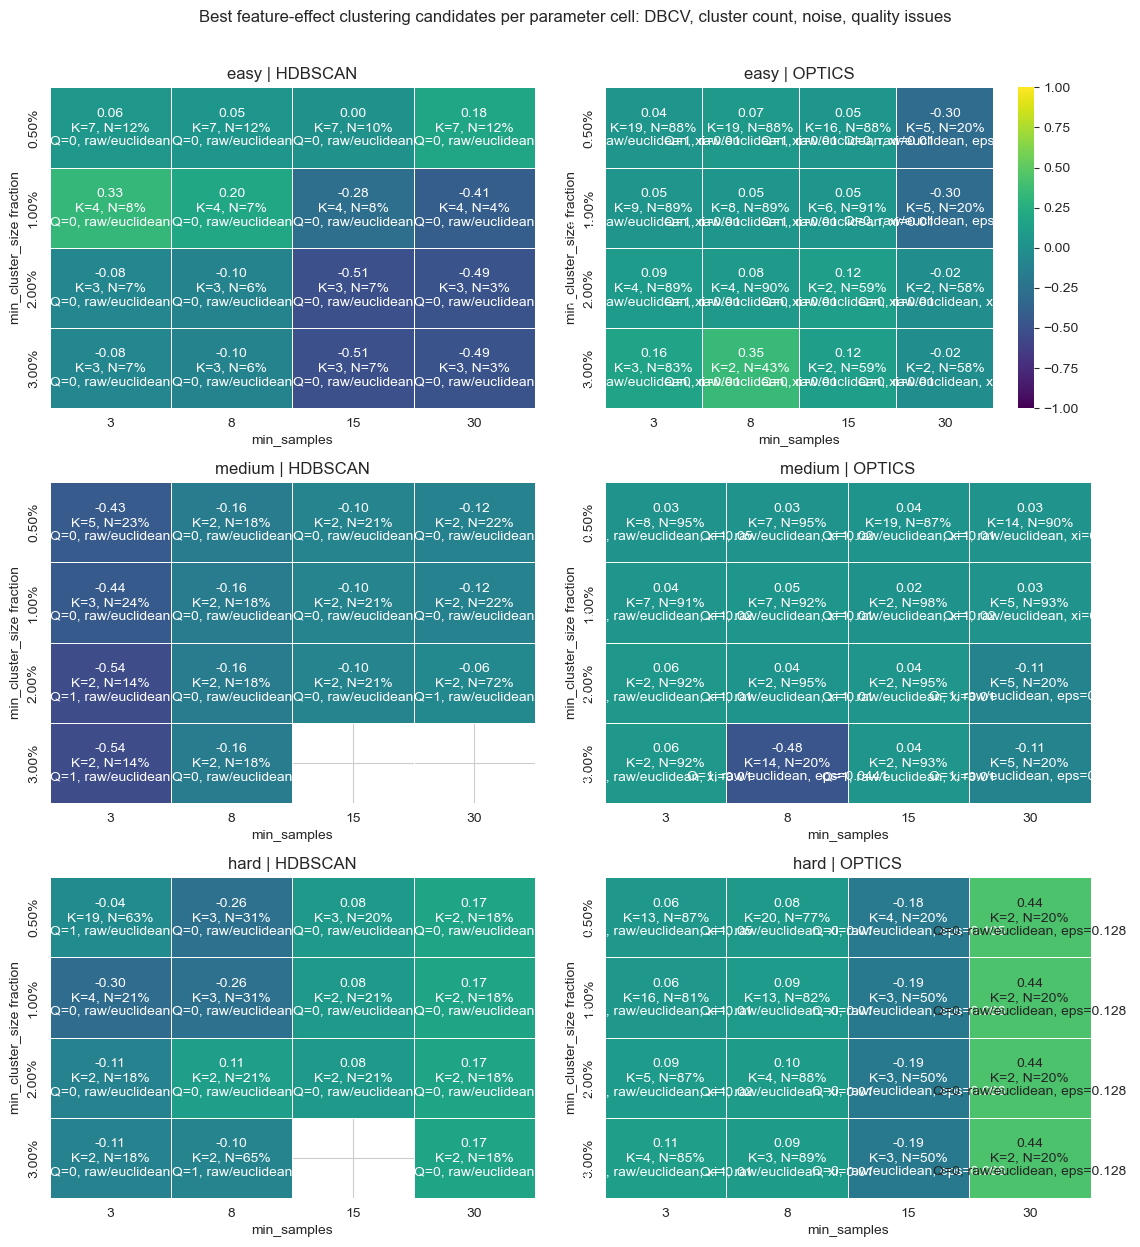

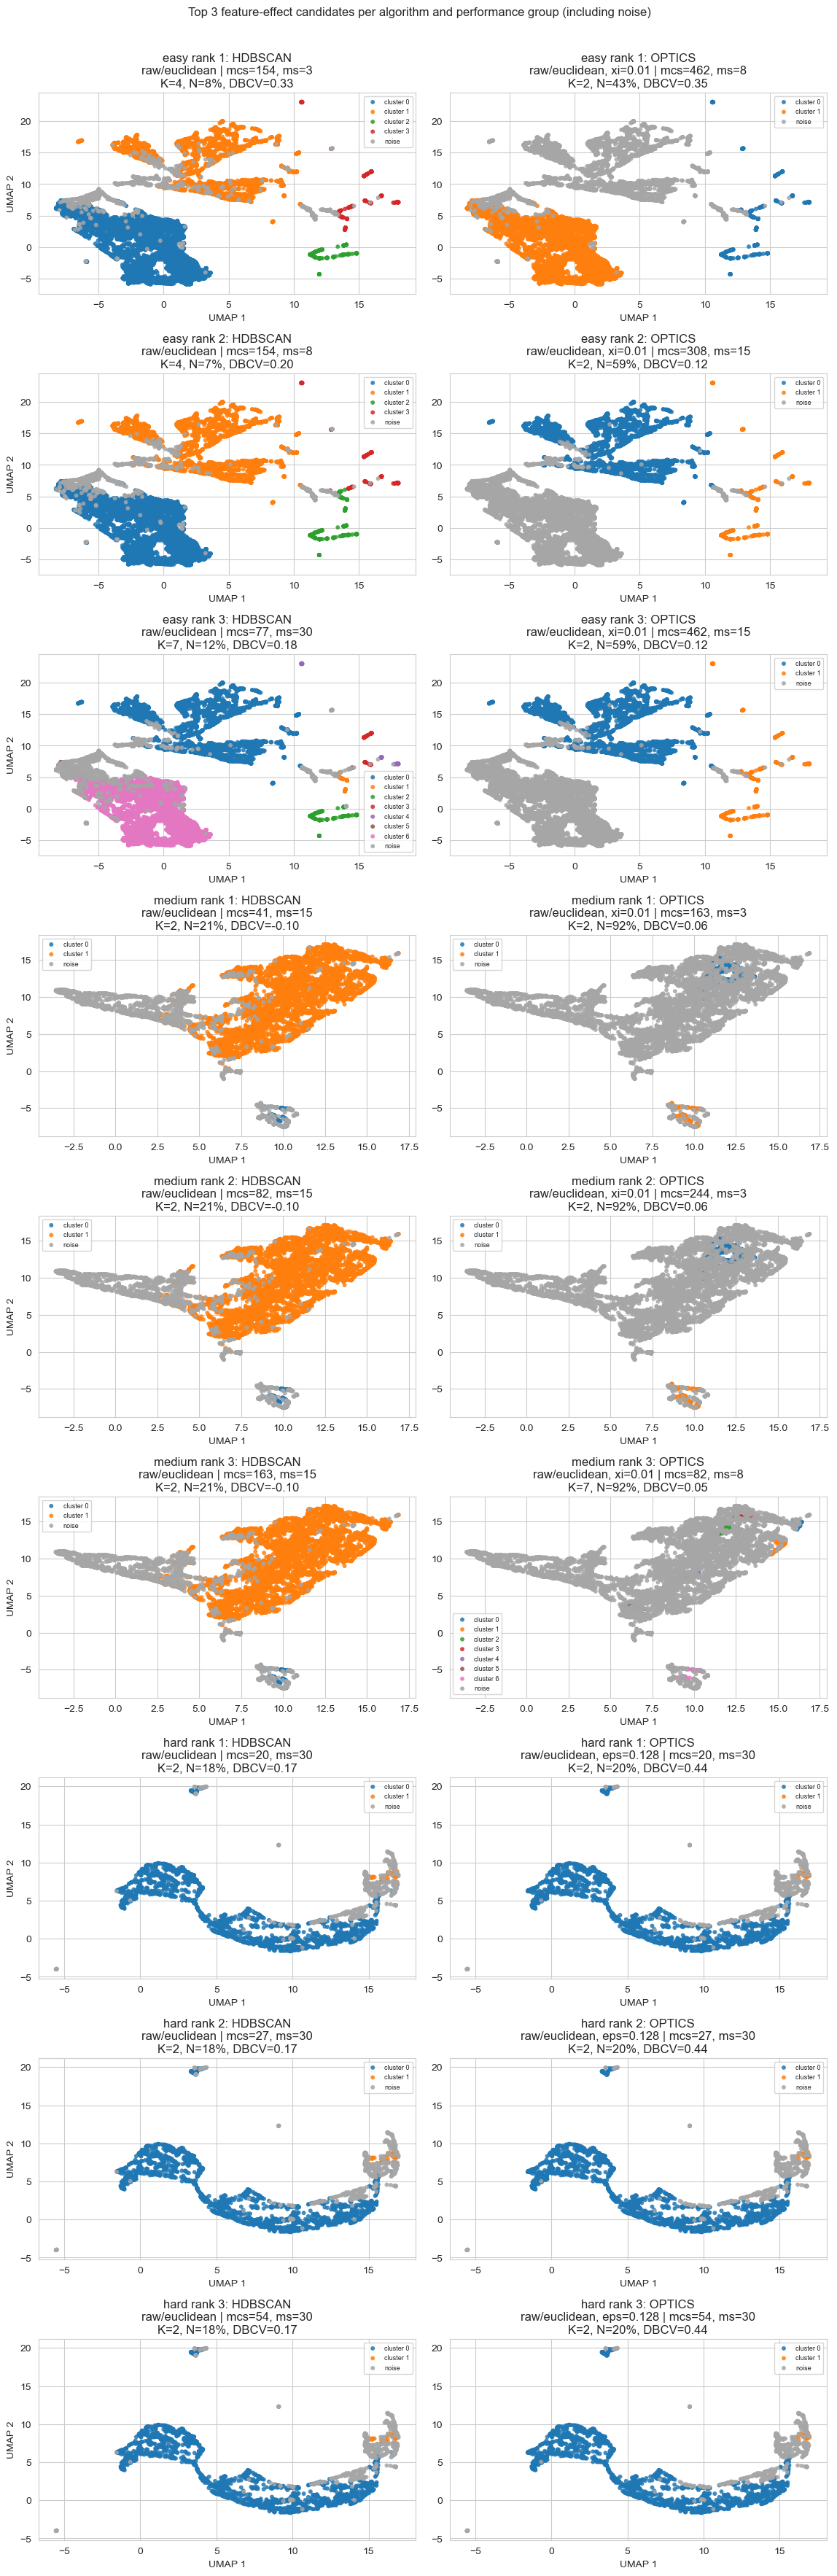

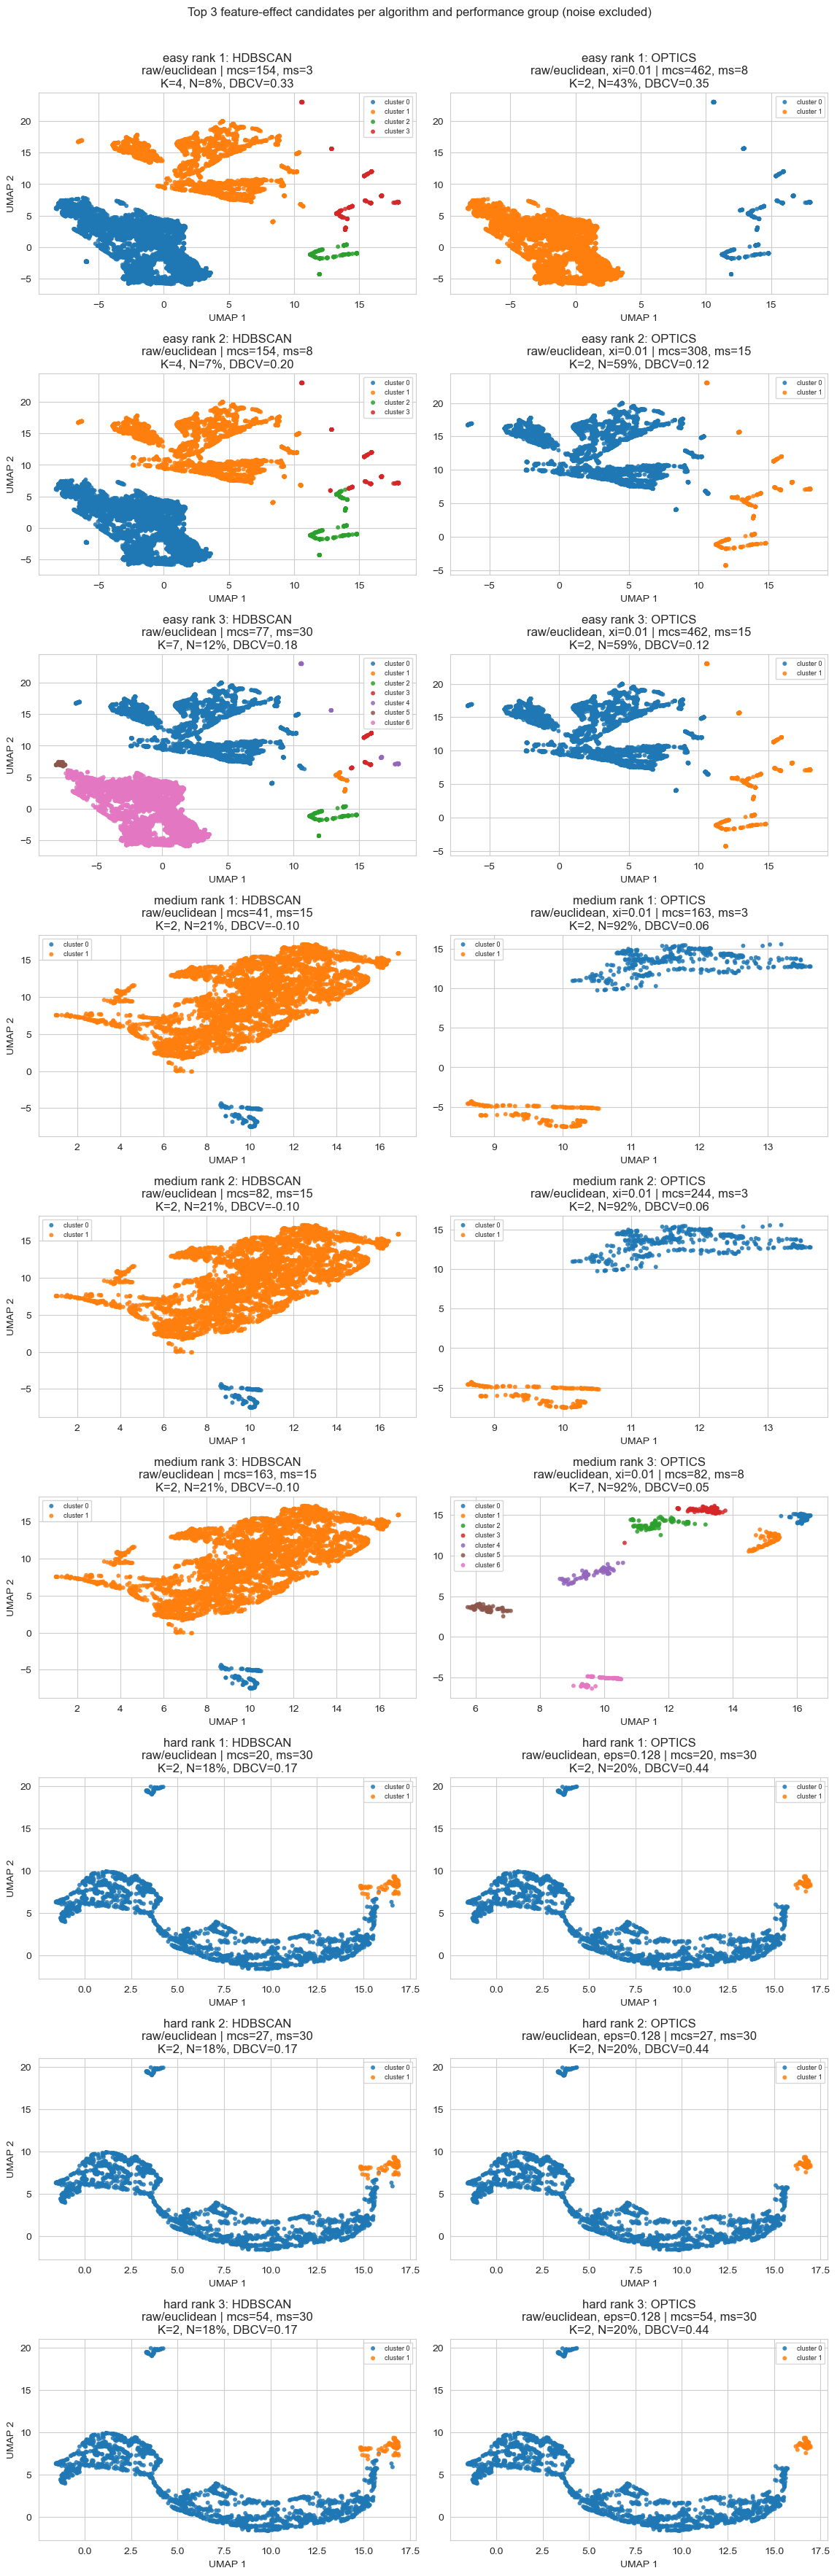

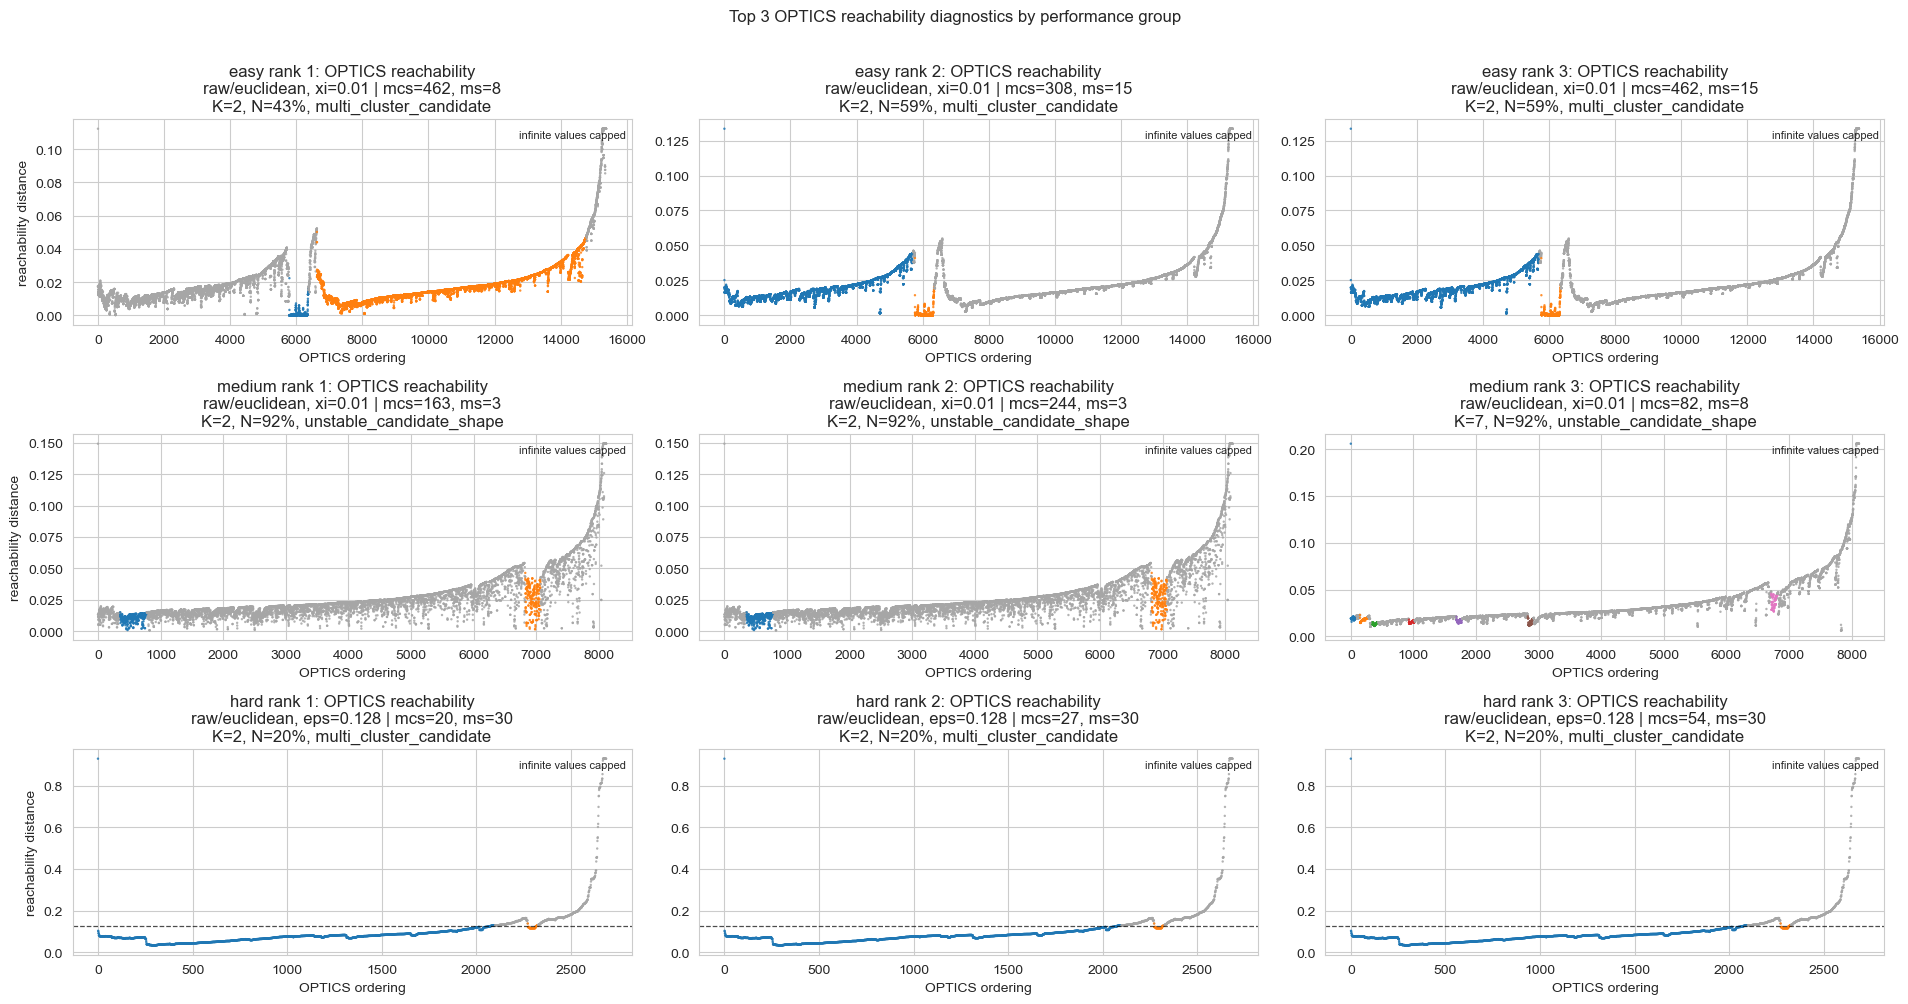

Recommended feature-effect clustering runs:


,selected_for_group,performance_group,algorithm,cluster_space,distance_metric,optics_extraction_method,min_cluster_size_fraction,min_cluster_size,min_samples,optics_xi,optics_eps,n_clusters,noise_fraction,largest_cluster_share,quality_issue_count,passes_conservative_quality_screen,optics_xi_no_stable_valley,optics_xi_status,dbcv_raw_effect_space,candidate_label_col
92,True,easy,optics,raw,euclidean,xi,0.030,462,8,0.01,NaN,2,0.432074,0.530338,0,True,False,multi_cluster_candidate,0.347042,cluster_optics_raw__mcs-frac-0p03__mcs-462__ms...
251,True,hard,optics,raw,euclidean,dbscan_eps,0.005,20,30,NaN,0.127768,2,0.198362,0.781169,0,True,False,multi_cluster_candidate,0.437072,cluster_optics_raw__mcs-frac-0p005__mcs-20__ms...
126,True,medium,hdbscan,raw,euclidean,,0.005,41,15,NaN,NaN,2,0.212394,0.765800,0,True,False,,-0.099698,cluster_hdbscan_raw__mcs-frac-0p005__mcs-41__m...


Top 3 candidates per algorithm and performance group:


,candidate_rank_for_algorithm,selected_for_group,performance_group,algorithm,cluster_space,distance_metric,optics_extraction_method,min_cluster_size_fraction,min_cluster_size,min_samples,...,optics_eps,n_clusters,noise_fraction,largest_cluster_share,quality_issue_count,passes_conservative_quality_screen,optics_xi_no_stable_valley,optics_xi_status,dbcv_raw_effect_space,candidate_label_col
0,1,False,easy,hdbscan,raw,euclidean,,0.010,154,3,...,NaN,4,0.081355,0.535605,0,True,False,,0.333787,cluster_hdbscan_raw__mcs-frac-0p01__mcs-154__ms-3
1,2,False,easy,hdbscan,raw,euclidean,,0.010,154,8,...,NaN,4,0.070170,0.526761,0,True,False,,0.195024,cluster_hdbscan_raw__mcs-frac-0p01__mcs-154__ms-8
2,3,False,easy,hdbscan,raw,euclidean,,0.005,77,30,...,NaN,7,0.116213,0.472979,0,True,False,,0.180907,cluster_hdbscan_raw__mcs-frac-0p005__mcs-77__m...
3,1,True,easy,optics,raw,euclidean,xi,0.030,462,8,...,NaN,2,0.432074,0.530338,0,True,False,multi_cluster_candidate,0.347042,cluster_optics_raw__mcs-frac-0p03__mcs-462__ms...
4,2,False,easy,optics,raw,euclidean,xi,0.020,308,15,...,NaN,2,0.590492,0.371334,0,True,False,multi_cluster_candidate,0.117029,cluster_optics_raw__mcs-frac-0p02__mcs-308__ms...
5,3,False,easy,optics,raw,euclidean,xi,0.030,462,15,...,NaN,2,0.590492,0.371334,0,True,False,multi_cluster_candidate,0.117029,cluster_optics_raw__mcs-frac-0p03__mcs-462__ms...
6,1,False,hard,hdbscan,raw,euclidean,,0.005,20,30,...,NaN,2,0.180499,0.788240,0,True,False,,0.166486,cluster_hdbscan_raw__mcs-frac-0p005__mcs-20__m...
7,2,False,hard,hdbscan,raw,euclidean,,0.010,27,30,...,NaN,2,0.180499,0.788240,0,True,False,,0.166486,cluster_hdbscan_raw__mcs-frac-0p01__mcs-27__ms-30
8,3,False,hard,hdbscan,raw,euclidean,,0.020,54,30,...,NaN,2,0.180499,0.788240,0,True,False,,0.166486,cluster_hdbscan_raw__mcs-frac-0p02__mcs-54__ms-30
9,1,True,hard,optics,raw,euclidean,dbscan_eps,0.005,20,30,...,0.127768,2,0.198362,0.781169,0,True,False,multi_cluster_candidate,0.437072,cluster_optics_raw__mcs-frac-0p005__mcs-20__ms...


Candidate quality issue counts:


,performance_group,algorithm,cluster_space,distance_metric,optics_extraction_method,min_cluster_size_fraction,min_cluster_size,min_samples,optics_xi,optics_eps,n_clusters,noise_fraction,largest_cluster_share,quality_issue_count,passes_conservative_quality_screen,optics_xi_no_stable_valley,optics_xi_status,dbcv_raw_effect_space
92,easy,optics,raw,euclidean,xi,0.030,462,8,0.01,NaN,2,0.432074,0.530338,0,True,False,multi_cluster_candidate,0.347042
28,easy,hdbscan,raw,euclidean,,0.010,154,3,NaN,NaN,4,0.081355,0.535605,0,True,False,,0.333787
35,easy,hdbscan,raw,euclidean,,0.010,154,8,NaN,NaN,4,0.070170,0.526761,0,True,False,,0.195024
21,easy,hdbscan,raw,euclidean,,0.005,77,30,NaN,NaN,7,0.116213,0.472979,0,True,False,,0.180907
71,easy,optics,raw,euclidean,xi,0.020,308,15,0.01,NaN,2,0.590492,0.371334,0,True,False,multi_cluster_candidate,0.117029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,medium,optics,raw,euclidean,dbscan_eps,0.030,244,8,NaN,0.019238,42,0.794752,0.118763,3,False,True,unstable_candidate_shape,-0.033228
116,medium,optics,raw,euclidean,dbscan_eps,0.005,41,3,NaN,0.013688,372,0.754096,0.030430,3,False,True,unstable_candidate_shape,NaN
144,medium,optics,raw,euclidean,dbscan_eps,0.010,82,3,NaN,0.013688,372,0.754096,0.030430,3,False,True,unstable_candidate_shape,NaN
172,medium,optics,raw,euclidean,dbscan_eps,0.020,163,3,NaN,0.013688,372,0.754096,0.030430,3,False,True,unstable_candidate_shape,NaN


In [8]:
def _format_candidate_fraction(value: object) -> str:
    if pd.isna(value):
        return "single"
    return f"{float(value):.2%}".rstrip("0").rstrip(".")


def _format_dbcv(value: object) -> str:
    return "NaN" if pd.isna(value) else f"{float(value):.2f}"


def _format_xi(value: object) -> str:
    return "-" if pd.isna(value) else f"{float(value):.3g}"


def _format_eps(value: object) -> str:
    return "-" if pd.isna(value) else f"{float(value):.3g}"


def _format_optics_extraction(row: pd.Series) -> str:
    extraction_method = str(row.get("optics_extraction_method", "") or "")
    if extraction_method == "xi":
        return f"xi={_format_xi(row.get('optics_xi'))}"
    if extraction_method == "dbscan_eps":
        return f"eps={_format_eps(row.get('optics_eps'))}"
    return "-"


def _format_candidate_setting(row: pd.Series) -> str:
    base = f"{row.get('cluster_space', '-')}/{row.get('distance_metric', '-')}"
    if str(row.get("algorithm", "")) == "optics":
        return f"{base}, {_format_optics_extraction(row)}"
    return base


def rank_candidate_scores(cluster_scores_df: pd.DataFrame) -> pd.DataFrame:
    ranked_df = cluster_scores_df.copy()
    ranked_df["valid_for_selection_priority"] = (
        ranked_df["valid_for_selection"].astype(bool).astype(int)
    )
    ranked_df["dbcv_rank"] = ranked_df["dbcv_raw_effect_space"].fillna(-np.inf)
    ranked_df["cluster_space_priority"] = (
        ranked_df["cluster_space"]
        .map({"raw": 0, "normalized": 1, "umap": 2})
        .fillna(99)
    )
    ranked_df["distance_metric_priority"] = (
        ranked_df["distance_metric"]
        .map({"euclidean": 0, "manhattan": 1, "cityblock": 1, "cosine": 2})
        .fillna(50)
    )
    ranked_df["optics_extraction_priority"] = (
        ranked_df["optics_extraction_method"]
        .map({"": 0, "xi": 1, "dbscan_eps": 2})
        .fillna(50)
    )
    return ranked_df.sort_values(
        [
            "performance_group",
            "algorithm",
            "valid_for_selection_priority",
            "quality_issue_count",
            "dbcv_rank",
            "noise_fraction",
            "n_clusters",
            "cluster_space_priority",
            "distance_metric_priority",
            "min_cluster_size",
            "min_samples",
            "optics_extraction_priority",
            "optics_xi",
            "optics_eps",
            "score_row_id",
        ],
        ascending=[
            True,
            True,
            False,
            True,
            False,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
        ],
        na_position="last",
    )


def select_top_candidates_by_algorithm(
    cluster_scores_df: pd.DataFrame,
    *,
    top_n: int = 3,
) -> pd.DataFrame:
    ranked_df = rank_candidate_scores(cluster_scores_df)
    top_df = (
        ranked_df.groupby(["performance_group", "algorithm"], as_index=False)
        .head(top_n)
        .copy()
    )
    top_df["candidate_rank_for_algorithm"] = (
        top_df.groupby(["performance_group", "algorithm"]).cumcount() + 1
    )
    return top_df.reset_index(drop=True)


algorithm_top_runs_df = select_top_candidates_by_algorithm(
    cluster_scores_df,
    top_n=EXPORT_TOP_CANDIDATES_PER_GROUP_ALGORITHM,
)
algorithm_best_runs_df = algorithm_top_runs_df.loc[
    algorithm_top_runs_df["candidate_rank_for_algorithm"] == 1
].copy()


def plot_candidate_score_heatmap_grid(
    cluster_scores_df: pd.DataFrame,
    *,
    plot_path: Path,
) -> None:
    groups = CLUSTER_SPEC_RESOLVED["groups"]
    algorithms = CLUSTER_SPEC_RESOLVED["algorithms"]
    fig, axes = plt.subplots(
        len(groups),
        len(algorithms),
        figsize=(5.8 * len(algorithms), 4.1 * len(groups)),
        squeeze=False,
    )

    for row_idx, performance_group in enumerate(groups):
        for col_idx, algorithm in enumerate(algorithms):
            ax = axes[row_idx][col_idx]
            plot_df = cluster_scores_df.loc[
                (cluster_scores_df["performance_group"] == performance_group)
                & (cluster_scores_df["algorithm"] == algorithm)
            ].copy()
            if plot_df.empty:
                ax.set_visible(False)
                continue

            plot_df["mcs_fraction_label"] = plot_df["min_cluster_size_fraction"].map(
                _format_candidate_fraction
            )
            plot_df = rank_candidate_scores(plot_df).drop_duplicates(
                subset=["mcs_fraction_label", "min_samples"],
                keep="first",
            )
            heatmap_df = plot_df.pivot_table(
                index="mcs_fraction_label",
                columns="min_samples",
                values="dbcv_raw_effect_space",
                aggfunc="first",
            )
            ordered_fraction_labels = [
                _format_candidate_fraction(value)
                for value in sorted(
                    plot_df["min_cluster_size_fraction"].dropna().unique()
                )
            ]
            if plot_df["min_cluster_size_fraction"].isna().any():
                ordered_fraction_labels = ["single"] + ordered_fraction_labels
            if not ordered_fraction_labels:
                ordered_fraction_labels = sorted(heatmap_df.index.tolist())
            heatmap_df = heatmap_df.reindex(
                index=ordered_fraction_labels,
                columns=sorted(heatmap_df.columns.tolist()),
            )

            annotations = heatmap_df.copy().astype(object)
            for fraction_label in heatmap_df.index:
                for min_samples in heatmap_df.columns:
                    cell_rows = plot_df.loc[
                        (plot_df["mcs_fraction_label"] == fraction_label)
                        & (plot_df["min_samples"] == min_samples)
                    ]
                    if cell_rows.empty:
                        annotations.loc[fraction_label, min_samples] = ""
                        continue
                    row = cell_rows.iloc[0]
                    annotations.loc[fraction_label, min_samples] = (
                        f"{_format_dbcv(row['dbcv_raw_effect_space'])}\n"
                        f"K={int(row['n_clusters'])}, N={row['noise_fraction']:.0%}\n"
                        f"Q={int(row['quality_issue_count'])}, {_format_candidate_setting(row)}"
                    )

            sns.heatmap(
                heatmap_df,
                annot=annotations,
                fmt="",
                cmap="viridis",
                vmin=-1,
                vmax=1,
                linewidths=0.5,
                linecolor="white",
                cbar=row_idx == 0 and col_idx == len(algorithms) - 1,
                ax=ax,
            )
            ax.set_title(f"{performance_group} | {algorithm.upper()}")
            ax.set_xlabel("min_samples")
            ax.set_ylabel("min_cluster_size fraction")

    fig.suptitle(
        "Best feature-effect clustering candidates per parameter cell: DBCV, cluster count, noise, quality issues",
        y=1.01,
    )
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_algorithm_candidate_umap(
    clustered_df: pd.DataFrame,
    algorithm_top_runs_df: pd.DataFrame,
    *,
    plot_path: Path,
    include_noise: bool,
) -> None:
    groups = CLUSTER_SPEC_RESOLVED["groups"]
    algorithms = CLUSTER_SPEC_RESOLVED["algorithms"]
    top_n = int(algorithm_top_runs_df["candidate_rank_for_algorithm"].max())
    fig, axes = plt.subplots(
        len(groups) * top_n,
        len(algorithms),
        figsize=(5.8 * len(algorithms), 3.9 * len(groups) * top_n),
        squeeze=False,
    )

    for group_idx, performance_group in enumerate(groups):
        for rank_idx in range(top_n):
            row_idx = group_idx * top_n + rank_idx
            candidate_rank = rank_idx + 1
            for col_idx, algorithm in enumerate(algorithms):
                ax = axes[row_idx][col_idx]
                selected_rows = algorithm_top_runs_df.loc[
                    (algorithm_top_runs_df["performance_group"] == performance_group)
                    & (algorithm_top_runs_df["algorithm"] == algorithm)
                    & (
                        algorithm_top_runs_df["candidate_rank_for_algorithm"]
                        == candidate_rank
                    )
                ]
                if selected_rows.empty:
                    ax.text(
                        0.5,
                        0.5,
                        "No candidate",
                        ha="center",
                        va="center",
                        transform=ax.transAxes,
                    )
                    ax.set_axis_off()
                    continue

                selected_row = selected_rows.iloc[0]
                label_col = selected_row["candidate_label_col"]
                group_df = clustered_df.loc[
                    clustered_df[PERFORMANCE_GROUP_COL] == performance_group
                ].copy()
                group_df[label_col] = pd.to_numeric(
                    group_df[label_col], errors="coerce"
                ).astype("Int64")
                if not include_noise:
                    group_df = group_df.loc[group_df[label_col] != -1].copy()

                ordered_cluster_ids = sorted(
                    cluster_id
                    for cluster_id in group_df[label_col]
                    .dropna()
                    .astype(int)
                    .unique()
                    .tolist()
                    if cluster_id != -1
                )
                if include_noise and int((group_df[label_col] == -1).sum()) > 0:
                    ordered_cluster_ids.append(-1)

                if not ordered_cluster_ids:
                    ax.text(
                        0.5,
                        0.5,
                        "No non-noise rows",
                        ha="center",
                        va="center",
                        transform=ax.transAxes,
                    )
                    ax.set_axis_off()
                    continue

                palette = sns.color_palette(
                    "tab10",
                    n_colors=max(len([c for c in ordered_cluster_ids if c != -1]), 1),
                )
                color_lookup = {
                    cluster_id: palette[idx % len(palette)]
                    for idx, cluster_id in enumerate(
                        cluster_id
                        for cluster_id in ordered_cluster_ids
                        if cluster_id != -1
                    )
                }
                color_lookup[-1] = (0.65, 0.65, 0.65)

                for cluster_id in ordered_cluster_ids:
                    cluster_rows = group_df.loc[group_df[label_col] == cluster_id]
                    ax.scatter(
                        cluster_rows["viz_umap_x"],
                        cluster_rows["viz_umap_y"],
                        s=18,
                        alpha=0.86,
                        c=[color_lookup[cluster_id]],
                        edgecolors="none",
                        label="noise" if cluster_id == -1 else f"cluster {cluster_id}",
                    )

                ax.set_title(
                    f"{performance_group} rank {candidate_rank}: {algorithm.upper()}\n"
                    f"{_format_candidate_setting(selected_row)} | "
                    f"mcs={int(selected_row['min_cluster_size'])}, ms={int(selected_row['min_samples'])}\n"
                    f"K={int(selected_row['n_clusters'])}, N={selected_row['noise_fraction']:.0%}, "
                    f"DBCV={_format_dbcv(selected_row['dbcv_raw_effect_space'])}"
                )
                ax.set_xlabel("UMAP 1")
                ax.set_ylabel("UMAP 2" if col_idx == 0 else "")
                ax.legend(loc="best", fontsize=6.5, frameon=True)

    noise_label = "including noise" if include_noise else "noise excluded"
    fig.suptitle(
        f"Top 3 feature-effect candidates per algorithm and performance group ({noise_label})",
        y=1.005,
    )
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_optics_reachability_grid(
    clustered_df: pd.DataFrame,
    algorithm_top_runs_df: pd.DataFrame,
    *,
    plot_path: Path,
) -> None:
    import warnings
    from sklearn.cluster import OPTICS

    optics_top_runs_df = algorithm_top_runs_df.loc[
        algorithm_top_runs_df["algorithm"] == "optics"
    ].copy()
    groups = CLUSTER_SPEC_RESOLVED["groups"]
    top_n = (
        int(optics_top_runs_df["candidate_rank_for_algorithm"].max())
        if not optics_top_runs_df.empty
        else 1
    )
    fig, axes = plt.subplots(
        len(groups),
        top_n,
        figsize=(6.4 * top_n, 3.3 * len(groups)),
        squeeze=False,
    )

    for row_idx, performance_group in enumerate(groups):
        for rank_idx in range(top_n):
            candidate_rank = rank_idx + 1
            ax = axes[row_idx][rank_idx]
            selected_rows = optics_top_runs_df.loc[
                (optics_top_runs_df["performance_group"] == performance_group)
                & (optics_top_runs_df["candidate_rank_for_algorithm"] == candidate_rank)
            ]
            if selected_rows.empty:
                ax.text(
                    0.5,
                    0.5,
                    "No OPTICS candidate",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_axis_off()
                continue

            selected_row = selected_rows.iloc[0]
            cluster_space = str(selected_row.get("cluster_space", "raw"))
            if cluster_space == "umap":
                ax.text(
                    0.5,
                    0.5,
                    "Reachability refit skipped for UMAP-space candidate",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_axis_off()
                continue

            group_df = clustered_df.loc[
                clustered_df[PERFORMANCE_GROUP_COL] == performance_group
            ].copy()
            label_col = selected_row["candidate_label_col"]
            labels = (
                pd.to_numeric(group_df[label_col], errors="coerce")
                .fillna(-1)
                .astype(int)
                .to_numpy()
            )
            X_raw = group_df[effect_cols].to_numpy(dtype=float)
            X_space = build_effect_cluster_space_matrix(X_raw, cluster_space)
            distance_metric = str(selected_row.get("distance_metric", "euclidean"))
            with warnings.catch_warnings():
                warnings.filterwarnings(
                    "ignore",
                    message="divide by zero encountered in divide",
                    category=RuntimeWarning,
                    module="sklearn.cluster._optics",
                )
                optics_model = OPTICS(
                    min_samples=int(selected_row["min_samples"]),
                    min_cluster_size=int(selected_row["min_cluster_size"]),
                    xi=0.05,
                    metric=distance_metric,
                    cluster_method="xi",
                ).fit(X_space)

            ordered_reachability = optics_model.reachability_[optics_model.ordering_]
            ordered_labels = labels[optics_model.ordering_]
            finite_reachability = ordered_reachability[
                np.isfinite(ordered_reachability)
            ]
            if finite_reachability.size:
                y_cap = float(np.quantile(finite_reachability, 0.995))
                plot_reachability = np.where(
                    np.isfinite(ordered_reachability),
                    np.minimum(ordered_reachability, y_cap),
                    y_cap,
                )
            else:
                y_cap = 1.0
                plot_reachability = np.zeros_like(ordered_reachability, dtype=float)

            cluster_ids = sorted(
                cluster_id
                for cluster_id in set(ordered_labels.astype(int))
                if cluster_id != -1
            )
            palette = sns.color_palette("tab10", n_colors=max(len(cluster_ids), 1))
            color_lookup = {
                cluster_id: palette[idx % len(palette)]
                for idx, cluster_id in enumerate(cluster_ids)
            }
            color_lookup[-1] = (0.65, 0.65, 0.65)
            colors = [color_lookup[int(label)] for label in ordered_labels]
            ax.scatter(
                np.arange(len(plot_reachability)),
                plot_reachability,
                s=3,
                c=colors,
                alpha=0.85,
                linewidths=0,
            )
            if str(selected_row.get("optics_extraction_method", "")) == "dbscan_eps":
                eps_value = selected_row.get("optics_eps", np.nan)
                if not pd.isna(eps_value):
                    ax.axhline(
                        float(eps_value),
                        color="black",
                        linestyle="--",
                        linewidth=0.9,
                        alpha=0.7,
                    )
            ax.set_title(
                f"{performance_group} rank {candidate_rank}: OPTICS reachability\n"
                f"{_format_candidate_setting(selected_row)} | "
                f"mcs={int(selected_row['min_cluster_size'])}, ms={int(selected_row['min_samples'])}\n"
                f"K={int(selected_row['n_clusters'])}, N={selected_row['noise_fraction']:.0%}, "
                f"{selected_row.get('optics_xi_status', '')}"
            )
            ax.set_xlabel("OPTICS ordering")
            ax.set_ylabel("reachability distance" if rank_idx == 0 else "")
            if finite_reachability.size and np.isinf(ordered_reachability).any():
                ax.text(
                    0.99,
                    0.95,
                    "infinite values capped",
                    ha="right",
                    va="top",
                    fontsize=8,
                    transform=ax.transAxes,
                )

    fig.suptitle("Top 3 OPTICS reachability diagnostics by performance group", y=1.01)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_candidate_score_heatmap_grid(
    cluster_scores_df,
    plot_path=CANDIDATE_SCORE_HEATMAP_GRID_PATH,
)
plot_algorithm_candidate_umap(
    clustered_df,
    algorithm_top_runs_df,
    plot_path=ALGORITHM_CANDIDATE_UMAP_PATH,
    include_noise=True,
)
plot_algorithm_candidate_umap(
    clustered_df,
    algorithm_top_runs_df,
    plot_path=ALGORITHM_CANDIDATE_UMAP_NO_NOISE_PATH,
    include_noise=False,
)
plot_optics_reachability_grid(
    clustered_df,
    algorithm_top_runs_df,
    plot_path=OPTICS_REACHABILITY_GRID_PATH,
)

print("Recommended feature-effect clustering runs:")
display(best_cluster_runs_df[score_display_cols])
print("Top 3 candidates per algorithm and performance group:")
display(algorithm_top_runs_df[["candidate_rank_for_algorithm"] + score_display_cols])
print("Candidate quality issue counts:")
display(
    cluster_scores_df[
        [
            "performance_group",
            "algorithm",
            "cluster_space",
            "distance_metric",
            "optics_extraction_method",
            "min_cluster_size_fraction",
            "min_cluster_size",
            "min_samples",
            "optics_xi",
            "optics_eps",
            "n_clusters",
            "noise_fraction",
            "largest_cluster_share",
            "quality_issue_count",
            "passes_conservative_quality_screen",
            "optics_xi_no_stable_valley",
            "optics_xi_status",
            "dbcv_raw_effect_space",
        ]
    ].sort_values(
        ["performance_group", "quality_issue_count", "dbcv_raw_effect_space"],
        ascending=[True, True, False],
    )
)

## Assemble Candidate-Wide Cluster Exports
**Purpose:** Build lean downstream exports for every candidate cluster subset without duplicating the authoritative assignment table, and copy the run-level global feature-effect ranking into the cluster-spec export tree.<br>
**Inputs:** `clustered_df`, `cluster_scores_df`, resolved export paths, `raw_metric_col`, `effect_cols`, and `feature_effect_ranking_df`.<br>
**Outputs:** Downstream-filtered `cluster_feature_effect_profiles_df`, `cluster_catalog_df`, one slim member file per exported cluster subset, and `feature_effect_global_ranking.csv` for downstream inspection ordering.<br>
**How to Verify:** Confirm that the catalog includes every `(performance group, algorithm, cluster space, cluster_id)` subset, including noise when present, and that the copied ranking table preserves the run-level global order.


In [ ]:
missing_downstream_quality_cols = [
    col
    for col in DOWNSTREAM_QUALITY_FLAG_COLUMNS
    if col not in cluster_scores_df.columns
]
if missing_downstream_quality_cols:
    raise KeyError(
        "Cluster scores are missing downstream quality flag columns: "
        f"{missing_downstream_quality_cols}"
    )

downstream_cluster_mask = (
    cluster_scores_df["dbcv_raw_effect_space"].fillna(-np.inf)
    > DOWNSTREAM_MIN_DBCV_RAW_EFFECT_SPACE
) & (
    cluster_scores_df["noise_fraction"].fillna(np.inf) <= DOWNSTREAM_MAX_NOISE_FRACTION
)
for quality_flag_col in DOWNSTREAM_QUALITY_FLAG_COLUMNS:
    downstream_cluster_mask &= (
        ~cluster_scores_df[quality_flag_col].fillna(False).astype(bool)
    )

downstream_cluster_scores_df = rank_candidate_scores(
    cluster_scores_df.loc[downstream_cluster_mask].copy()
).reset_index(drop=True)
if downstream_cluster_scores_df.empty:
    raise ValueError(
        "No clustering candidates passed the downstream export requirements: "
        f"dbcv_raw_effect_space > {DOWNSTREAM_MIN_DBCV_RAW_EFFECT_SPACE}, "
        f"noise_fraction <= {DOWNSTREAM_MAX_NOISE_FRACTION}, "
        f"and no quality flags in {DOWNSTREAM_QUALITY_FLAG_COLUMNS}."
    )

all_candidate_label_cols = sorted(
    cluster_scores_df["candidate_label_col"].dropna().astype(str).unique()
)
downstream_candidate_label_cols = sorted(
    downstream_cluster_scores_df["candidate_label_col"].dropna().astype(str).unique()
)
dropped_candidate_label_cols = [
    col
    for col in all_candidate_label_cols
    if col not in set(downstream_candidate_label_cols)
]
downstream_clustered_df = clustered_df.drop(
    columns=dropped_candidate_label_cols,
    errors="ignore",
)

print(
    "Downstream cluster export candidates: "
    f"{len(downstream_cluster_scores_df)} of {len(cluster_scores_df)} scored candidates; "
    f"{len(downstream_candidate_label_cols)} candidate label columns retained."
)
print(
    "Downstream filter: "
    f"dbcv_raw_effect_space > {DOWNSTREAM_MIN_DBCV_RAW_EFFECT_SPACE}, "
    f"noise_fraction <= {DOWNSTREAM_MAX_NOISE_FRACTION}, "
    f"quality flags excluded: {DOWNSTREAM_QUALITY_FLAG_COLUMNS}. "
    "The boundary-cluster diagnostic is retained in scores but not required for export."
)

cluster_export_outputs = write_cluster_exports(
    downstream_clustered_df,
    downstream_cluster_scores_df,
    export_layout=EXPORT_LAYOUT,
    performance_metric_col=raw_metric_col,
    performance_group_col=PERFORMANCE_GROUP_COL,
    effect_cols=effect_cols,
)

cluster_feature_effect_profiles_df = cluster_export_outputs[
    "cluster_feature_effect_profiles_df"
]
cluster_catalog_df = cluster_export_outputs["cluster_catalog_df"]
feature_effect_ranking_df.to_csv(FEATURE_EFFECT_GLOBAL_RANKING_PATH, index=False)

if (
    cluster_export_outputs["cluster_feature_effect_profiles_path"]
    != CLUSTER_FEATURE_EFFECT_PROFILES_PATH
):
    raise ValueError(
        "Cluster feature-effect profile export path mismatch between notebook and export helper."
    )
if cluster_export_outputs["cluster_catalog_path"] != CLUSTER_CATALOG_PATH:
    raise ValueError(
        "Cluster catalog export path mismatch between notebook and export helper."
    )

print(f"Cluster profile rows: {len(cluster_feature_effect_profiles_df)}")
print(f"Cluster catalog rows: {len(cluster_catalog_df)}")
print(f"Copied global ranking rows: {len(feature_effect_ranking_df)}")

display(cluster_catalog_df.head())
display(cluster_feature_effect_profiles_df.head())
display(feature_effect_ranking_df.head())

Cluster profile rows: 14261
Cluster catalog rows: 14261
Copied global ranking rows: 5


,performance_group,algorithm,cluster_space,distance_metric,optics_extraction_method,optics_eps,candidate_label_col,cluster_id,cluster_label,is_noise,cluster_size,cluster_size_share,cluster_rank_by_size,unique_scene_step_count,unique_scene_count,members_relative_path
0,easy,hdbscan,raw,euclidean,,NaN,cluster_hdbscan_raw__mcs-frac-0p005__mcs-77__m...,6,cluster_6,False,7494,0.487351,1.0,1901,134,tables/cluster_members__group-easy__alg-hdbsca...
1,easy,hdbscan,raw,euclidean,,NaN,cluster_hdbscan_raw__mcs-frac-0p005__mcs-77__m...,4,cluster_4,False,5677,0.369188,2.0,1892,124,tables/cluster_members__group-easy__alg-hdbsca...
2,easy,hdbscan,raw,euclidean,,NaN,cluster_hdbscan_raw__mcs-frac-0p005__mcs-77__m...,1,cluster_1,False,193,0.012551,3.0,106,16,tables/cluster_members__group-easy__alg-hdbsca...
3,easy,hdbscan,raw,euclidean,,NaN,cluster_hdbscan_raw__mcs-frac-0p005__mcs-77__m...,2,cluster_2,False,139,0.009039,4.0,70,10,tables/cluster_members__group-easy__alg-hdbsca...
4,easy,hdbscan,raw,euclidean,,NaN,cluster_hdbscan_raw__mcs-frac-0p005__mcs-77__m...,5,cluster_5,False,134,0.008714,5.0,125,39,tables/cluster_members__group-easy__alg-hdbsca...


,performance_group,algorithm,cluster_space,distance_metric,optics_extraction_method,optics_eps,candidate_label_col,cluster_id,cluster_label,is_noise,cluster_size,cluster_size_share,effect__std_speed,effect__max_speed,effect__heading_change_per_sec,effect__mean_acceleration,effect__min_neighbor_distance,cluster_rank_by_size
0,easy,hdbscan,raw,euclidean,,NaN,cluster_hdbscan_raw__mcs-frac-0p01__mcs-154__ms-3,0,cluster_0,False,8236,0.535605,-1.780986,0.477029,-0.203661,0.521968,0.034909,1
1,easy,hdbscan,raw,euclidean,,NaN,cluster_hdbscan_raw__mcs-frac-0p01__mcs-154__ms-8,0,cluster_0,False,8100,0.526761,-1.783765,0.476997,-0.206806,0.521707,0.034854,1
2,easy,hdbscan,raw,euclidean,,NaN,cluster_hdbscan_raw__mcs-frac-0p02__mcs-308__ms-3,0,cluster_0,False,8236,0.535605,-1.780986,0.477029,-0.203661,0.521968,0.034909,1
3,easy,hdbscan,raw,euclidean,,NaN,cluster_hdbscan_raw__mcs-frac-0p03__mcs-462__ms-3,0,cluster_0,False,8236,0.535605,-1.780986,0.477029,-0.203661,0.521968,0.034909,1
4,easy,hdbscan,raw,euclidean,,NaN,cluster_hdbscan_raw__mcs-frac-0p02__mcs-308__ms-8,0,cluster_0,False,8100,0.526761,-1.783765,0.476997,-0.206806,0.521707,0.034854,1


,feature,global_rank,p_value,neg_log10_p_value,significant_0_05,importance_metric,importance_value,importance_ascending
0,heading_change_per_sec,1,1.110223e-16,15.95459,True,p_value,1.110223e-16,True
1,max_speed,2,1.110223e-16,15.95459,True,p_value,1.110223e-16,True
2,mean_acceleration,3,1.110223e-16,15.95459,True,p_value,1.110223e-16,True
3,min_neighbor_distance,4,1.110223e-16,15.95459,True,p_value,1.110223e-16,True
4,std_speed,5,1.110223e-16,15.95459,True,p_value,1.110223e-16,True


## Export Regime Artifacts
**Purpose:** Persist the assembled regime table, downstream-filtered clustering outputs, candidate diagnostic plots, the full candidate score audit table, and the copied global feature-effect ranking for downstream interpretation.<br>
**Inputs:** The completed notebook dataframes, export-helper outputs, and the plot paths accumulated in earlier sections.<br>
**Outputs:** CSV exports, saved plot files, and a manifest table that records only the main clustering artifacts required by downstream notebooks.<br>
**How to Verify:** Check that every printed output path exists under the run-specific results directory and that the manifest records the neutral feature-effect artifact names.


In [ ]:
analysis_df.to_csv(REGIME_ANALYSIS_PATH, index=False)
group_summary_df.to_csv(PERFORMANCE_GROUP_SUMMARY_PATH, index=False)
trustworthiness_df.to_csv(UMAP_TRUSTWORTHINESS_PATH, index=False)
downstream_cluster_scores_df.to_csv(CLUSTER_SCORES_PATH, index=False)
cluster_scores_df.to_csv(CLUSTER_SCORES_ALL_CANDIDATES_PATH, index=False)
# `cluster_assignments.csv` is downstream-facing and keeps only candidate label columns
# that passed the export requirements, alongside the joined table and visual embedding.
downstream_clustered_df.to_csv(CLUSTER_ASSIGNMENTS_PATH, index=False)

current_artifact_records = [
    {
        "artifact_kind": "table",
        "artifact_type": "regime_analysis",
        "relative_path": str(
            REGIME_ANALYSIS_PATH.relative_to(EXPORT_LAYOUT["cluster_spec_root"])
        ),
        "absolute_path": str(REGIME_ANALYSIS_PATH.resolve()),
    },
    {
        "artifact_kind": "table",
        "artifact_type": "performance_group_summary",
        "relative_path": str(
            PERFORMANCE_GROUP_SUMMARY_PATH.relative_to(
                EXPORT_LAYOUT["cluster_spec_root"]
            )
        ),
        "absolute_path": str(PERFORMANCE_GROUP_SUMMARY_PATH.resolve()),
    },
    {
        "artifact_kind": "table",
        "artifact_type": "umap_trustworthiness",
        "relative_path": str(
            UMAP_TRUSTWORTHINESS_PATH.relative_to(EXPORT_LAYOUT["cluster_spec_root"])
        ),
        "absolute_path": str(UMAP_TRUSTWORTHINESS_PATH.resolve()),
    },
    {
        "artifact_kind": "table",
        "artifact_type": "cluster_scores",
        "relative_path": str(
            CLUSTER_SCORES_PATH.relative_to(EXPORT_LAYOUT["cluster_spec_root"])
        ),
        "absolute_path": str(CLUSTER_SCORES_PATH.resolve()),
    },
    {
        "artifact_kind": "table",
        "artifact_type": "cluster_scores_all_candidates",
        "relative_path": str(
            CLUSTER_SCORES_ALL_CANDIDATES_PATH.relative_to(
                EXPORT_LAYOUT["cluster_spec_root"]
            )
        ),
        "absolute_path": str(CLUSTER_SCORES_ALL_CANDIDATES_PATH.resolve()),
    },
    {
        "artifact_kind": "table",
        "artifact_type": "cluster_assignments",
        "relative_path": str(
            CLUSTER_ASSIGNMENTS_PATH.relative_to(EXPORT_LAYOUT["cluster_spec_root"])
        ),
        "absolute_path": str(CLUSTER_ASSIGNMENTS_PATH.resolve()),
    },
    {
        "artifact_kind": "table",
        "artifact_type": "feature_effect_global_ranking",
        "relative_path": str(
            FEATURE_EFFECT_GLOBAL_RANKING_PATH.relative_to(
                EXPORT_LAYOUT["cluster_spec_root"]
            )
        ),
        "absolute_path": str(FEATURE_EFFECT_GLOBAL_RANKING_PATH.resolve()),
    },
    {
        "artifact_kind": "plot",
        "artifact_type": "candidate_score_heatmap_grid",
        "relative_path": str(
            CANDIDATE_SCORE_HEATMAP_GRID_PATH.relative_to(
                EXPORT_LAYOUT["cluster_spec_root"]
            )
        ),
        "absolute_path": str(CANDIDATE_SCORE_HEATMAP_GRID_PATH.resolve()),
    },
    {
        "artifact_kind": "plot",
        "artifact_type": "algorithm_candidate_umap",
        "relative_path": str(
            ALGORITHM_CANDIDATE_UMAP_PATH.relative_to(
                EXPORT_LAYOUT["cluster_spec_root"]
            )
        ),
        "absolute_path": str(ALGORITHM_CANDIDATE_UMAP_PATH.resolve()),
    },
    {
        "artifact_kind": "plot",
        "artifact_type": "algorithm_candidate_umap_no_noise",
        "relative_path": str(
            ALGORITHM_CANDIDATE_UMAP_NO_NOISE_PATH.relative_to(
                EXPORT_LAYOUT["cluster_spec_root"]
            )
        ),
        "absolute_path": str(ALGORITHM_CANDIDATE_UMAP_NO_NOISE_PATH.resolve()),
    },
    {
        "artifact_kind": "plot",
        "artifact_type": "optics_reachability_grid",
        "relative_path": str(
            OPTICS_REACHABILITY_GRID_PATH.relative_to(
                EXPORT_LAYOUT["cluster_spec_root"]
            )
        ),
        "absolute_path": str(OPTICS_REACHABILITY_GRID_PATH.resolve()),
    },
]
for trustworthiness_view, plot_path in UMAP_TRUSTWORTHINESS_PLOT_PATHS.items():
    current_artifact_records.append(
        {
            "artifact_kind": "plot",
            "artifact_type": "umap_trustworthiness_curve",
            "trustworthiness_view": trustworthiness_view,
            "relative_path": str(
                plot_path.relative_to(EXPORT_LAYOUT["cluster_spec_root"])
            ),
            "absolute_path": str(plot_path.resolve()),
        }
    )
current_artifact_records.extend(cluster_export_outputs["artifact_records"])

manifest_data = load_or_initialize_feature_effect_regime_manifest(
    EXPORT_MANIFEST_PATH,
    run_context={
        "model_id": MODEL_ID,
        "run_name": RUN_NAME,
        "target_col": target_col,
        "target_mode": target_mode,
        "eval_csv_name": EVAL_CSV_NAME,
        "joined_metrics_run_name": JOINED_METRICS_RUN_NAME,
        "run_manifest_path": str(run_ctx.manifest_path),
        "prepared_data_path": str(PREPARED_DATA_PATH),
        "prepared_data_metadata_path": str(PREPARED_DATA_METADATA_PATH),
        "feature_effects_path": str(FEATURE_EFFECTS_PATH),
        "feature_effect_importance_path": str(FEATURE_EFFECT_IMPORTANCE_PATH),
        "joined_metrics_path": str(JOINED_METRICS_PATH),
        "cluster_effect_selection_rule": CLUSTER_EFFECT_SELECTION_RULE,
        "included_effect_features": included_effect_features,
        "excluded_effect_features": excluded_effect_features,
        "cluster_effect_exclusion_reason": CLUSTER_EFFECT_EXCLUSION_REASON,
    },
    data_context={
        "target_col": target_col,
        "eval_csv_name": EVAL_CSV_NAME,
        "lower_is_better": LOWER_IS_BETTER,
        "performance_group_col": PERFORMANCE_GROUP_COL,
        "data_context_slug": EXPORT_CONTEXT["data_context_slug"],
    },
    cluster_spec={
        "raw": CLUSTER_SPEC,
        "resolved": CLUSTER_SPEC_RESOLVED,
        "readable_slug": EXPORT_LAYOUT["cluster_spec_readable_slug"],
        "hash": EXPORT_LAYOUT["cluster_spec_hash"],
        "dirname": EXPORT_LAYOUT["cluster_spec_dirname"],
    },
)
manifest_data = merge_feature_effect_regime_artifact_records(
    manifest_data,
    artifact_records=current_artifact_records,
)
EXPORT_MANIFEST_PATH.write_text(json.dumps(manifest_data, indent=2))
artifact_manifest_df = pd.DataFrame(manifest_data["artifacts"])

print("Saved artifacts:")
print(f"- Run manifest:                 {run_ctx.manifest_path}")
print(f"- Prepared data export:         {PREPARED_DATA_PATH}")
print(f"- Prepared data metadata:       {PREPARED_DATA_METADATA_PATH}")
print(f"- Feature-effect export:        {FEATURE_EFFECTS_PATH}")
print(f"- Feature-effect importance:    {FEATURE_EFFECT_IMPORTANCE_PATH}")
print(f"- Cluster effect selection:     {CLUSTER_EFFECT_SELECTION_RULE}")
print(f"- Included effect features:     {included_effect_features}")
print(f"- Excluded effect features:     {excluded_effect_features}")
print(f"- Joined metrics run:           {JOINED_METRICS_RUN_NAME}")
print(f"- Joined metrics export:        {JOINED_METRICS_PATH}")
print(f'- Cluster-spec export root:     {EXPORT_LAYOUT["cluster_spec_root"]}')
print(f"- Export manifest:              {EXPORT_MANIFEST_PATH}")
print(f"- Regime analysis table:        {REGIME_ANALYSIS_PATH}")
print(f"- Performance group summary:    {PERFORMANCE_GROUP_SUMMARY_PATH}")
print(f"- UMAP trustworthiness:         {UMAP_TRUSTWORTHINESS_PATH}")
for trustworthiness_view, plot_path in UMAP_TRUSTWORTHINESS_PLOT_PATHS.items():
    print(f"- Trustworthiness curve ({trustworthiness_view}): {plot_path}")
print(f"- Cluster scores (downstream):  {CLUSTER_SCORES_PATH}")
print(f"- Cluster scores (all candidates): {CLUSTER_SCORES_ALL_CANDIDATES_PATH}")
print(f"- Cluster assignments:          {CLUSTER_ASSIGNMENTS_PATH}")
print(f"- Cluster feature-effect profiles: {CLUSTER_FEATURE_EFFECT_PROFILES_PATH}")
print(f"- Cluster catalog:              {CLUSTER_CATALOG_PATH}")
print(f"- Copied global ranking:        {FEATURE_EFFECT_GLOBAL_RANKING_PATH}")
print(f"- Candidate score heatmap:      {CANDIDATE_SCORE_HEATMAP_GRID_PATH}")
print(f"- Algorithm candidate UMAP:     {ALGORITHM_CANDIDATE_UMAP_PATH}")
print(f"- Algorithm candidate UMAP no-noise: {ALGORITHM_CANDIDATE_UMAP_NO_NOISE_PATH}")
print(f"- OPTICS reachability grid:     {OPTICS_REACHABILITY_GRID_PATH}")
print(f"- Tables directory:             {TABLES_DIR}")
print(f"- Plot directory:               {PLOTS_DIR}")

display(artifact_manifest_df)

Saved artifacts:
- Run manifest:                 <repo>/results/interpretable_model/gam/full_trainval_12ep_1seed/tables/run_manifest_ml_ade_log.json
- Prepared data export:         ../../results/interpretable_model/prepared_data/full_trainval_12ep_1seed/prepared_data_ml_ade.csv
- Feature-effect export:        <repo>/results/interpretable_model/gam/full_trainval_12ep_1seed/tables/feature_effects_ml_ade_log.csv
- Feature-effect importance:    <repo>/results/interpretable_model/gam/full_trainval_12ep_1seed/tables/feature_effect_importance_ml_ade_log.csv
- Joined metrics export:        ../../results/trajectory_prediction/trajectory_metrics_joined/full_trainval_12ep_1seed/eval_epoch_12.csv
- Cluster-spec export root:     <repo>/results/interpretable_model/feature_effect_performance_regimes/gam/full_trainval_12ep_1seed/ml_ade_log/target-ml_ade_log__eval-eval_epoch_12.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__spaces-raw_

,artifact_kind,artifact_type,relative_path,absolute_path,performance_group,algorithm,cluster_space,distance_metric,optics_extraction_method,optics_eps,candidate_label_col,cluster_id,is_noise,cluster_size
0,plot,algorithm_candidate_umap,plots/algorithm_candidate_umap.png,/… Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,plot,algorithm_candidate_umap_no_noise,plots/algorithm_candidate_umap__noise-excluded...,/… Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,plot,candidate_score_heatmap_grid,plots/candidate_score_heatmap_grid.png,/… Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,plot,optics_reachability_grid,plots/optics_reachability_grid.png,/… Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,table,cluster_assignments,tables/cluster_assignments.csv,/… Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14268,table,cluster_scores,tables/cluster_scores.csv,/… Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14269,table,feature_effect_global_ranking,tables/feature_effect_global_ranking.csv,/… Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14270,table,performance_group_summary,tables/performance_group_summary.csv,/… Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14271,table,regime_analysis,tables/regime_analysis.csv,/… Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
